In [1]:
import random
import dill 
import datetime as dt
import glob 
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pandas as pd
import scipy.spatial as spatial
import sys 
wd=".."
sys.path.append(wd+'//CPN//')
import numpy as np 
import statsmodels.api as sm
from tqdm import tqdm_notebook, tqdm
import brokenaxes
import math
import os

In [2]:
def make_dir(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)

In [3]:
def making_glob_work_properly(subfolder_to_search):
    wd=os.getcwd(); os.chdir(wd+"/"+subfolder_to_search+'/')
    set_of_h5_files= glob.glob("*")
    os.chdir(wd)
    return set_of_h5_files

In [4]:
## A series of functions to parse the  simulation output
def get_run_uuid(sim_output, **kwargs):
    sim_id, sim_data = sim_output
    return(sim_id['uuid'])

def get_run_random_seed(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    random_seed = sim_ids['np.random.seed']
    return(random_seed)

def get_num_echoes_heard(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    num_echoes_heard = np.sum(sim_data[0])
    return(num_echoes_heard)

which_echo = {True: 1 , False:0}

def get_echoids(sim_data, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    echo_indices = np.argwhere(sim_data[0]==which_echo[heard]).flatten()
    return(echo_indices)    

def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output
    echo_ids = get_echoids(sim_data, **kwargs)
    
    echo_levels = sim_data[1]['target_echoes'].loc[echo_ids,'level']
    return(echo_levels)
    

def get_group_size(sim_output, **kwargs):
    ''' This function is necessary because of the
    stupid way I stored the parameter sets using classes
    '''
    sim_ids, sim_data = sim_output
    num_bats_in_group = sim_data[0].size +1 
    return(num_bats_in_group)

def split_by_groupsize(df):
    all_subdfs = []
    group_sizes = np.unique(df['groupsize'])
    for each_groupsize in group_sizes:
        subdf = df[df['groupsize']==each_groupsize]
        all_subdfs.append(subdf)
    return(group_sizes, all_subdfs)



def get_individual_positions(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    _, _b, geometry = sim_data
    positions = geometry['positions']
    return(positions)


def get_detection_distance(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    individuals_inds = echo_inds +1 # because focal individ is 0 index
    all_positions = get_individual_positions(sim_output)
    heard_individual_positions = all_positions[individuals_inds,:]
    focal_ind = all_positions[0,:]
    distances = spatial.distance
    
    positions_of_relevance = np.row_stack((focal_ind, heard_individual_positions))
    distances = spatial.distance_matrix(positions_of_relevance, 
                                        positions_of_relevance)[1:,0]
    return(distances)

def get_detection_azimuth(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_azimuth = np.array(echoes['theta'][echo_inds])
    
    return(echo_azimuth)


def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_level = np.array(echoes['level'][echo_inds])
    
    return(echo_level)
    


def get_nearest_neighbour_distances(sim_output, **kwargs):
    '''Extract the distance to the nearest neighbour of the focal bat
    
    Parameters
    -----------
    sim_output : output from a simulation run. 
    
    Keyword Arguments
    ------------------
    nearest_nbrs : int.
                    The number of distance measurements given. 
                    Defaults to 5. 


    Returns
    ---------
    nearest_neighbour_distances : 1 x nearest_nbrs np.array
    '''
    nearest_nbrs = kwargs.get('nearest_nbrs',5)
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)[1:,0]
    nearest_neighbour_distances = np.sort(distances)[:nearest_nbrs]
    return(nearest_neighbour_distances)

def get_furthest_bat2bat_distance(sim_output, **kwargs):
    '''
    '''
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)
    furthest_distance = np.max(distances)
    return(furthest_distance)
    

def extract_parameter_values(one_sim_result, **kwargs):
    '''
    Extracts the variables from the simulation result
    by extracting the values from the 
    'parameter set'
    
    Parameters
    -----------
    one_sim_results : tuple/list with 2 entries. 
                      entry 1 should have the simulation identifiers
                      entry 2 may be anything.
    Keyword Arguments
    -----------------
    variables_to_extract : list with str.
                           The names of the variables that are to be extracted.
                           Notes: 
                           If 'source_level' is one of the variables - only the 
                           emitted levels as dBSPL is output - the reference distance
                           is *ignored*.

    Returns
    --------
    param_set : list.
                A list with the numeric or Boolean values of each of the variables extracted. 
    '''
    sim_identifiers, sim_data = one_sim_result
    all_parameter_values = sim_identifiers['parameter_set']
    
    param_set_for_this_run = []
    for each in kwargs['variables_to_extract']:
        if each != 'source_level':
            param_set_for_this_run.append(all_parameter_values[each])
        elif each == 'source_level':
            param_set_for_this_run.append(all_parameter_values[each]['dBSPL'])
    
    return(param_set_for_this_run)
        
make_to_string = lambda X: str(X)

def join_all_parameters(parameter_list):
    '''
    '''
    params_as_string = map(make_to_string, parameter_list)
    param_joined = '*'.join(params_as_string)
    return(param_joined)

def make_paramset_id(sim_output, **kwargs):
    '''
    '''
    all_parameter_values = extract_parameter_values(sim_output, **kwargs)
    param_id = join_all_parameters(all_parameter_values)
    return(param_id)


def load_simresult(path_to_simresult):
    '''
    '''
    with open(path_to_simresult, 'rb') as sim:
        output = dill.load(sim)
    return(output)

def load_and_extract(simresult_path, extraction_functions, **kwargs):
    '''
    Parameters
    ----------
    simresult_path : str/path object

    extraction_functions : list/tuple with one or more function that work on 
                            the simulation output

    Keyword Arguments
    -----------------
    As defined by the extraction functions. 
    Every key must be unique and correspond to a particular extraction function!

    Returns
    ---------
    extracted_output : object type thats returned by the extraction function
    '''
    simresult = load_simresult(simresult_path)
    extracted_outputs = [ extract(simresult, **kwargs) for extract in extraction_functions]
    return(extracted_outputs)

In [5]:
# Some functions that deal with formatting the simulation data after it's been loaded from the csv file. 

def format_nearest_neighbour_distances(nearest_nbr_entry):
    '''
    Parameters
    ----------
    nearest_nbr_entry : string. 
                        pd.DataFrame column entry with 
                        the following format 
                        '[<float>, <float>, <float>]'
    
    Returns
    -------
    np.array
    
    '''
    only_float_as_string = nearest_nbr_entry[1:-1]
    all_strings_separated = only_float_as_string.split()
    floats = map(lambda X : float(X), all_strings_separated)
    
    distances = np.array(floats)
    return(distances)
    
def split_parameters_joint_to_separate_columns(row, col_names):
    for colnam, value in zip(col_names, row['parameters_joint']):
        row[colnam] = value
    return(row)


In [6]:
results_folder = wd+'/simulations/effect_of_position_focal_bat_d/store_results_after_changes_to_threshold/'
list_of_folder_ids= glob.glob(results_folder+"*")
list_of_folder_ids= [i[len(results_folder):] for i in list_of_folder_ids]
list_of_folder_ids= np.sort(list_of_folder_ids)
# # glob.glob(results_folder+"*")
list_of_folder_ids
list_of_folder_ids_array_version= [i.split(",") for i in list_of_folder_ids]
list_of_folder_ids_array_version= [(n[0][1:],n[1][1:]) for n in list_of_folder_ids_array_version]
list_of_folder_ids_array_version= np.array([(float(n[0]), float(n[1])) for n in list_of_folder_ids_array_version])

In [7]:
def run_while_reanalysis_to_change_folder_ids(list_of_folder_ids):
    # results_folder = wd+'/analysis/task_type+'_*]'/store_results/'
    # # glob.glob(results_folder+"*")
    list_of_folder_ids_array_version= [i.split(",") for i in list_of_folder_ids]
    list_of_folder_ids_array_version= [(n[0][1:],n[1][1:]) for n in list_of_folder_ids_array_version]
    list_of_folder_ids_array_version= np.array([(float(n[0]), float(n[1])) for n in list_of_folder_ids_array_version])
    return list_of_folder_ids, list_of_folder_ids_array_version


In [8]:
list_of_folder_ids_array_version

array([[1.        , 1.57079633],
       [2.        , 1.57079633],
       [3.        , 1.57079633]])

In [9]:
folder_id= list_of_folder_ids[0]
all_results = glob.glob(results_folder+folder_id+'/*.simresults')
some_results =random.sample(all_results, int(len(all_results)*1.0))

In [10]:
extraction_fns = [get_num_echoes_heard, get_group_size, get_furthest_bat2bat_distance,
                 get_nearest_neighbour_distances, get_detection_distance, get_run_uuid,
                  get_run_random_seed,make_paramset_id, extract_parameter_values,
                 get_echo_levels, get_detection_azimuth]
keyword_arguments = {'nearest_nbrs':3}

In [11]:
keyword_arguments['variables_to_extract'] = ['heading_variation', 'echocall_duration','atmospheric_attenuation','min_spacing','source_level',
                        'interpulse_interval', 'implement_shadowing',
                                            ]

In [12]:
what_to_do = input('Do you want to "rerun" from scratch or 2, "reanalyse" from previous data')
task_type= input('What type of analysis is this?')

In [13]:
what_to_do

'rerun'

In [14]:
if what_to_do == 'rerun':
    array_containing_all_simulation_datasets_raw = []
    iterant=0
    yyyymmdd = dt.datetime.now()
    timestamp = str([yyyymmdd.year,yyyymmdd.month,yyyymmdd.day,yyyymmdd.hour])
    make_dir(task_type+'_data'+timestamp+"/")
    for folder_id in list_of_folder_ids:
        all_results = glob.glob(results_folder+str(folder_id)+'/*.simresults')
        some_results =random.sample(all_results, int(len(all_results)*1.0))
        
        %time extracted_simdata = Parallel(n_jobs=4)(delayed(load_and_extract)(each, extraction_fns, **keyword_arguments) for each in tqdm(some_results))
        # print(extracted_simdata)
        echoes_heard = []
        group_size = []
        group_diameter = []
        nearest_3nbrs = []
        nbr_detection_range = []
        uuid = []
        seed = []
        param_ids = []
        parameter_values = []
        echo_levels = []
        detection_angle = []
        for each in extracted_simdata:
            for variable, list_to_append in zip(each, [echoes_heard, group_size, group_diameter,
                                                    nearest_3nbrs, nbr_detection_range,
                                                    uuid, seed, param_ids, parameter_values,
                                                    echo_levels, detection_angle]):
                list_to_append.append(variable)
        simulation_data = pd.DataFrame(data = {'nbrs_detected':echoes_heard,
                                        'group_size':group_size,
                                        'group_diameter':group_diameter,
                                        'nearest_neighbour_distance':nearest_3nbrs,
                                        'nbrs_detected_distance':nbr_detection_range,
                                        'uuid':uuid,
                                        'seed':seed,
                                        'paramset_id':param_ids,
                                        'parameters_joint':parameter_values,
                                        'echo_levels':echo_levels,
                                        'detection_azimuth':detection_angle})
        column_names = keyword_arguments['variables_to_extract']

        for each in column_names:
            simulation_data[each] = np.nan

        %time simulation_data = simulation_data.apply(split_parameters_joint_to_separate_columns, 1, col_names=column_names)    
        

        simulation_data["focal_bat"]= len(simulation_data)*[list_of_folder_ids_array_version[iterant]]

        ##### thanks to https://realpython.com/fast-flexible-pandas/#but-i-heard-that-pandas-is-slow
        data_store = pd.HDFStore(task_type+'_data'+timestamp+'/'+folder_id+'.h5')
        data_store['simulation_data'] = simulation_data
        data_store.close()

        array_containing_all_simulation_datasets_raw.append(simulation_data)
        iterant+=1
        
if what_to_do == 'reanalyse':
    # show all datasets in the folder
    data_stores_in_folder = glob.glob(task_type+'_*]')

    datastores_by_index = pd.DataFrame(data={'data_stores':data_stores_in_folder})
    print(datastores_by_index)
    # user-inputs dataset choice:
    which_dataset = int(input('Give the index of the dataset you want to'))
    print()
    # load a pre-exisiting dataset
    #load the saved data 
    list_of_h5_files_in_folder= making_glob_work_properly(datastores_by_index["data_stores"][which_dataset])
    # print(list_of_h5_files_in_folder); print("./"+datastores_by_index["data_stores"][which_dataset]+'/*')
    array_containing_all_simulation_datasets_raw = []
    list_of_folder_ids, list_of_folder_ids_array_version= run_while_reanalysis_to_change_folder_ids(list_of_h5_files_in_folder)
    for h5_file in list_of_h5_files_in_folder:
        data_load = pd.HDFStore("./"+datastores_by_index["data_stores"][which_dataset]+'/'+h5_file)
        simulation_data = data_load['simulation_data']
        array_containing_all_simulation_datasets_raw.append(simulation_data)
        data_load.close()

else:
    raise IOError('Invalid input given!!')

100%|██████████| 400/400 [00:01<00:00, 391.79it/s]
/tmp/ipykernel_43354/2862285842.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 166 ms, sys: 9.19 ms, total: 175 ms
Wall time: 1.17 s
CPU times: user 22.8 ms, sys: 0 ns, total: 22.8 ms
Wall time: 22.8 ms


100%|██████████| 301/301 [00:00<00:00, 1453.59it/s]
/tmp/ipykernel_43354/2862285842.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 218 ms, sys: 3.39 ms, total: 221 ms
Wall time: 381 ms
CPU times: user 17.2 ms, sys: 17 μs, total: 17.2 ms
Wall time: 17.2 ms


100%|██████████| 200/200 [00:00<00:00, 1408.04it/s]
/tmp/ipykernel_43354/2862285842.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 138 ms, sys: 3.48 ms, total: 142 ms
Wall time: 252 ms
CPU times: user 11.8 ms, sys: 0 ns, total: 11.8 ms
Wall time: 11.8 ms


OSError: Invalid input given!!

In [ ]:
# list_of_folder_ids_array_version= [i.split(",") for i in list_of_folder_ids]
# list_of_folder_ids_array_version= [(n[0][1:], n[1][:-1]) for n in list_of_folder_ids_array_version]
# list_of_folder_ids_array_version= np.array([(float(n[0]), float(n[1])) for n in list_of_folder_ids_array_version])

# true_false_indices= list_of_folder_ids_array_version[:,1]==list_of_folder_ids_array_version[0,1]

In [15]:
simulation_data["focal_bat"][:]

0      [3.0, 1.5707963267948966]
1      [3.0, 1.5707963267948966]
2      [3.0, 1.5707963267948966]
3      [3.0, 1.5707963267948966]
4      [3.0, 1.5707963267948966]
                 ...            
195    [3.0, 1.5707963267948966]
196    [3.0, 1.5707963267948966]
197    [3.0, 1.5707963267948966]
198    [3.0, 1.5707963267948966]
199    [3.0, 1.5707963267948966]
Name: focal_bat, Length: 200, dtype: object

In [16]:
list_of_folder_ids_array_version

array([[1.        , 1.57079633],
       [2.        , 1.57079633],
       [3.        , 1.57079633]])

In [17]:
array_containing_all_simulation_datasets=[]

for simulation_data in array_containing_all_simulation_datasets_raw:
    if simulation_data["focal_bat"][0][0]==5.0 or simulation_data["focal_bat"][0][0]==6.0:
        continue
    else:
        array_containing_all_simulation_datasets.append(simulation_data)

In [18]:
def passing_true_false_indices_through_lists(list, true_false_list):
    """this is required since list doeesnt support numpy operations and non linear lists can hence not take in true false as indices"""
    output_array= []; iterant=0
    for entry in true_false_list:
        if entry:
            output_array.append(list[iterant])

        iterant+=1
    return output_array

In [19]:
array_containing_all_simulation_datasets

[     nbrs_detected  group_size  group_diameter  \
 0                9          20        2.943843   
 1                4           5        1.260983   
 2                4          10        1.718060   
 3                5          30        3.722741   
 4                3          30        3.778728   
 ..             ...         ...             ...   
 395              4          20        2.846537   
 396              1          30        3.803461   
 397              4          30        3.737207   
 398              3           5        1.353660   
 399              3           5        1.261803   
 
                             nearest_neighbour_distance  \
 0    [0.5375554709187624, 0.5601805407218439, 0.699...   
 1    [0.5096457845826217, 0.7028813610172225, 0.791...   
 2    [0.5002884290511059, 0.5022709441977719, 0.527...   
 3    [0.5016713616500572, 0.5101845278505015, 0.615...   
 4    [0.5233082657461481, 0.5661076240707686, 0.650...   
 ..                             

In [20]:
unique_angles_in_dataset= np.unique(list_of_folder_ids_array_version[:,1])
list_containing_simulated_data_sorted_by_angles= {}
for angle in unique_angles_in_dataset:
    list_containing_simulated_data_sorted_by_angles[angle]= []
    sublist_true_false_labels= list_of_folder_ids_array_version[:,1]==angle
    sublist_given_angle= passing_true_false_indices_through_lists(array_containing_all_simulation_datasets, sublist_true_false_labels)
    list_containing_simulated_data_sorted_by_angles[angle].append(sublist_given_angle)

In [21]:
list_of_folder_ids_array_version[:,1]==angle

array([ True,  True,  True])

In [22]:
list_containing_simulated_data_sorted_by_angles

{1.5707963267948966: [[     nbrs_detected  group_size  group_diameter  \
   0                9          20        2.943843   
   1                4           5        1.260983   
   2                4          10        1.718060   
   3                5          30        3.722741   
   4                3          30        3.778728   
   ..             ...         ...             ...   
   395              4          20        2.846537   
   396              1          30        3.803461   
   397              4          30        3.737207   
   398              3           5        1.353660   
   399              3           5        1.261803   
   
                               nearest_neighbour_distance  \
   0    [0.5375554709187624, 0.5601805407218439, 0.699...   
   1    [0.5096457845826217, 0.7028813610172225, 0.791...   
   2    [0.5002884290511059, 0.5022709441977719, 0.527...   
   3    [0.5016713616500572, 0.5101845278505015, 0.615...   
   4    [0.5233082657461481, 0.5661

In [23]:
for subset_given_angle in list_containing_simulated_data_sorted_by_angles:
    subset= list_containing_simulated_data_sorted_by_angles[subset_given_angle]
    for item in subset:
        subset

In [24]:
type(simulation_data["group_size"][0])

numpy.int64

1.5707963267948966


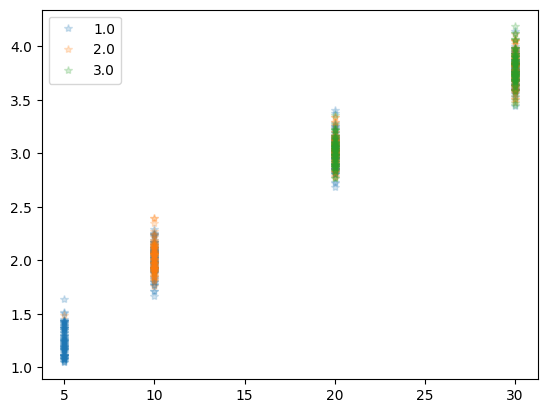

In [25]:
%matplotlib inline
i=0
for angle in list_containing_simulated_data_sorted_by_angles.keys():
    subset_given_angle= list_containing_simulated_data_sorted_by_angles[angle][0]
    print(angle)
    for simulation_data in subset_given_angle:
        plt.plot(simulation_data['group_size'],
                    simulation_data['group_diameter'], 
                '*',label=simulation_data["focal_bat"][0][0],alpha=0.2)
        i+=1
    plt.legend()
    plt.show()

In [26]:
simulation_data.keys()

Index(['nbrs_detected', 'group_size', 'group_diameter',
       'nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid', 'seed',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'echocall_duration', 'atmospheric_attenuation',
       'min_spacing', 'source_level', 'interpulse_interval',
       'implement_shadowing', 'focal_bat'],
      dtype='object')

In [27]:
by_minspacing = simulation_data.groupby('min_spacing')
nearest_nbr_dist = {}
for spacing, df in by_minspacing:
    nearest_nbr_distances = df['nearest_neighbour_distance'].reset_index(drop=True)
    nearest_nbr_dist[spacing] = np.concatenate(nearest_nbr_distances)
nearest_nbr_dists_for_plot = [nearest_nbr_dist[0.5]]

In [28]:
simulation_data["focal_bat"]

0      [3.0, 1.5707963267948966]
1      [3.0, 1.5707963267948966]
2      [3.0, 1.5707963267948966]
3      [3.0, 1.5707963267948966]
4      [3.0, 1.5707963267948966]
                 ...            
195    [3.0, 1.5707963267948966]
196    [3.0, 1.5707963267948966]
197    [3.0, 1.5707963267948966]
198    [3.0, 1.5707963267948966]
199    [3.0, 1.5707963267948966]
Name: focal_bat, Length: 200, dtype: object

/tmp/ipykernel_43354/866218751.py:17: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_43354/866218751.py:17: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_43354/866218751.py:17: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:


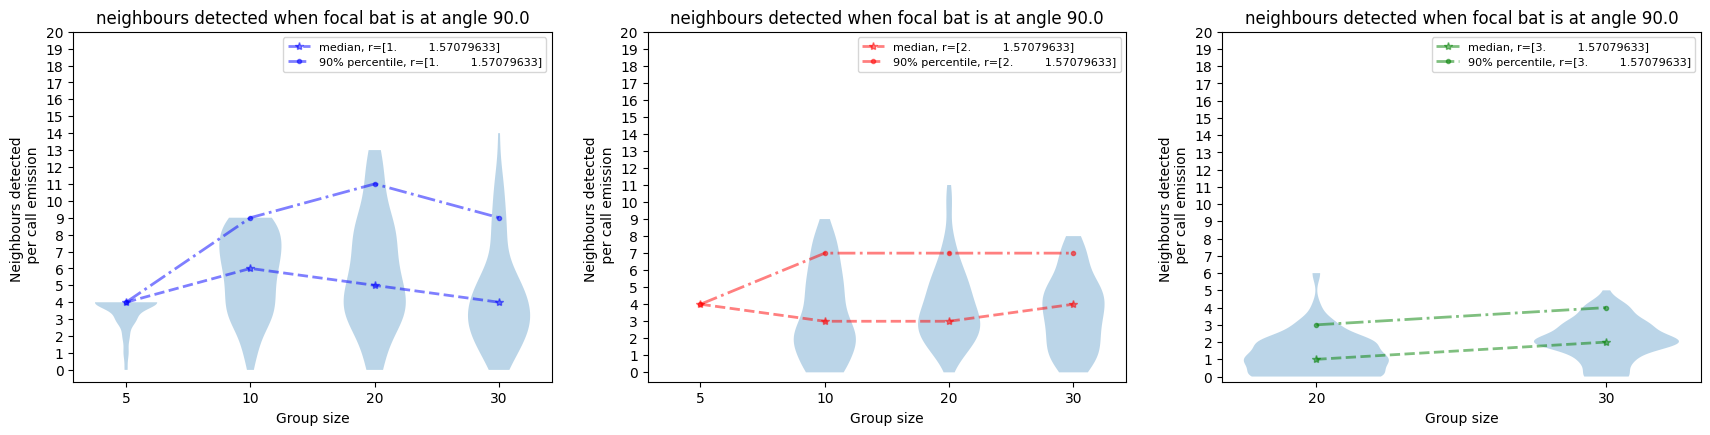

In [29]:
iterant1_axis=0
# fig, axs = plt.subplots(1,3, figsize=(27,9))


for angle in list_containing_simulated_data_sorted_by_angles.keys():
        subset_given_angle= list_containing_simulated_data_sorted_by_angles[angle][0]; iterant2_color=0
        colors=["blue", "red", "green", "black"]
        plt.figure(figsize=(21,10))
        i=1
        for simulation_data in subset_given_angle:
                data_by_groupsize = simulation_data.groupby(['group_size'])
                nbrs_detected_data = {}
                nbrs_detected_data['num_nbrs'] = []
                nbrs_detected_data['median_num_nbrs'] = []
                nbrs_detected_data['90%ile_num_nbrs'] = []
                groupsizes= []
                for groupsize, dataframe in data_by_groupsize:
                        groupsizes.append(groupsize)
                        nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                        nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                        nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

                breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5
                nbrs_detected_data['median_num_nbrs']

                # plt.figure(figsize=(7,3.42))
                plt.subplot(2,3,i)
                plt.violinplot(nbrs_detected_data['num_nbrs'][:], showextrema=False)
                plt.plot(np.arange(1,len(groupsizes)+1),nbrs_detected_data['median_num_nbrs'][:],
                        '--*',linewidth=2, alpha=0.5,label="median, r="+str(simulation_data["focal_bat"][0]), color= colors[iterant2_color])#'median')
                # print(np.arange(1,len(groupsizes)))
                plt.plot(np.arange(1,len(groupsizes)+1), nbrs_detected_data['90%ile_num_nbrs'][:],
                        '-..',linewidth=2, alpha=0.5, label="90% percentile, r="+str(simulation_data["focal_bat"][0]), color= colors[iterant2_color])#label='90%ile')
                # plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
                plt.yticks(np.arange(0,21,1))
                plt.xticks(range(1,len(groupsizes)+1),groupsizes[:])
                plt.legend(fontsize=8)
                plt.ylabel('Neighbours detected \n per call emission', fontsize=10)
                plt.xlabel('Group size', fontsize=10)
                # # plt.ylim(0,20)

                # axs[i].tight_layout()
                plt.title("neighbours detected when focal bat is at angle "+str(np.degrees(np.pi/2)))
                iterant2_color+=1; i+=1
                
        iterant1_axis+=1
                # plt.savefig('Figure2_groupsize_1200dpi.pdf',
                #         bbox_inches='tight', pad_inches=0.05, format='pdf', dpi=1200)
        
        # print(groupsizes); print(nbrs_detected_data['median_num_nbrs'])

In [31]:
np.unique(simulation_data["group_size"], return_counts=True)


(array([20, 30]), array([100, 100]))

1.5707963267948966


/tmp/ipykernel_43354/183471385.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


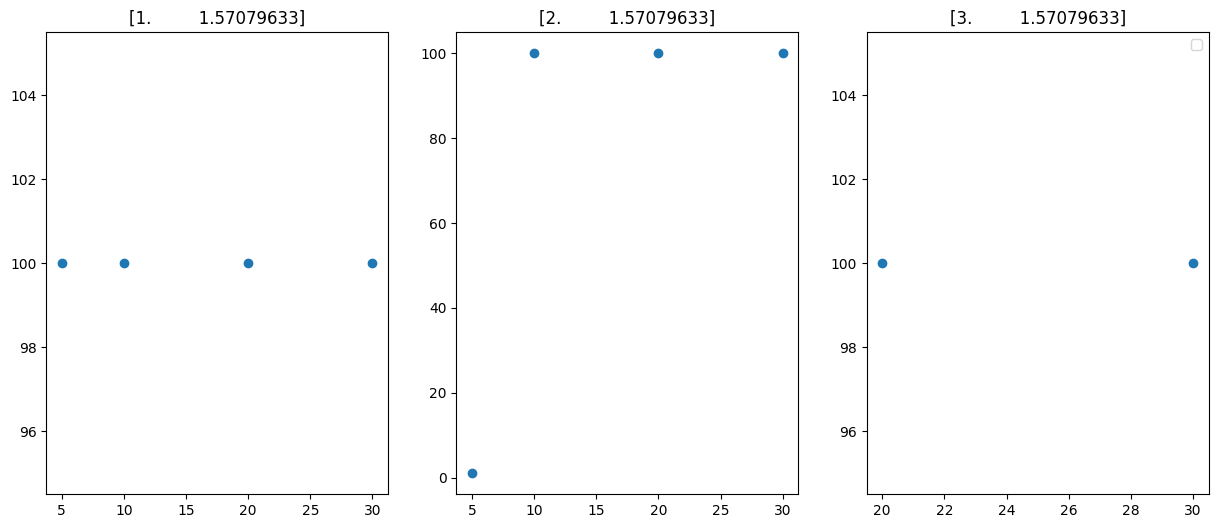

In [43]:
for angle in list_containing_simulated_data_sorted_by_angles.keys():
    subset_given_angle= list_containing_simulated_data_sorted_by_angles[angle][0]
    print(angle)
    i=0
    plt.figure(figsize=(15,6))
    for simulation_data in subset_given_angle:
        x,y= np.unique(simulation_data["group_size"], return_counts=True)
        plt.subplot(1,3,i+1)
        plt.scatter(x,y, alpha=1)
        plt.title(simulation_data["focal_bat"][0])
        i+=1
    plt.legend()
    plt.show()

# Verticle transect

moving from $(0.75, \frac {3pi}{2})$ to $(0.75, \frac {pi}{2})$ [r, theta] is similar to moving in a ($x=0$) transect centered at the centermost bat.
Note: All the heading vectors are in 90 degree direction ( $\pm$ 10 degree)

In [ ]:
transect_subsets= [[4, 3*np.pi/2],[3, 3*np.pi/2],[2, 3*np.pi/2],[1, 3*np.pi/2],[0.0,0.0],[1, np.pi/2],[2, np.pi/2], [3, np.pi/2], [4, np.pi/2]]
iterant_transect=0
sublist_of_simulation_data_intransect=[]
for r_theta in transect_subsets:
    for simulation_data in array_containing_all_simulation_datasets:
        if (simulation_data["focal_bat"][0]==r_theta).all():
            sublist_of_simulation_data_intransect.append(simulation_data)
sublist_true_false_labels            

array([False,  True,  True, False,  True, False,  True, False, False])

/tmp/ipykernel_41993/3869612641.py:12: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_41993/3869612641.py:12: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_41993/3869612641.py:12: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_41993/3869612641.py:12: FutureWarning: In a future version of pa

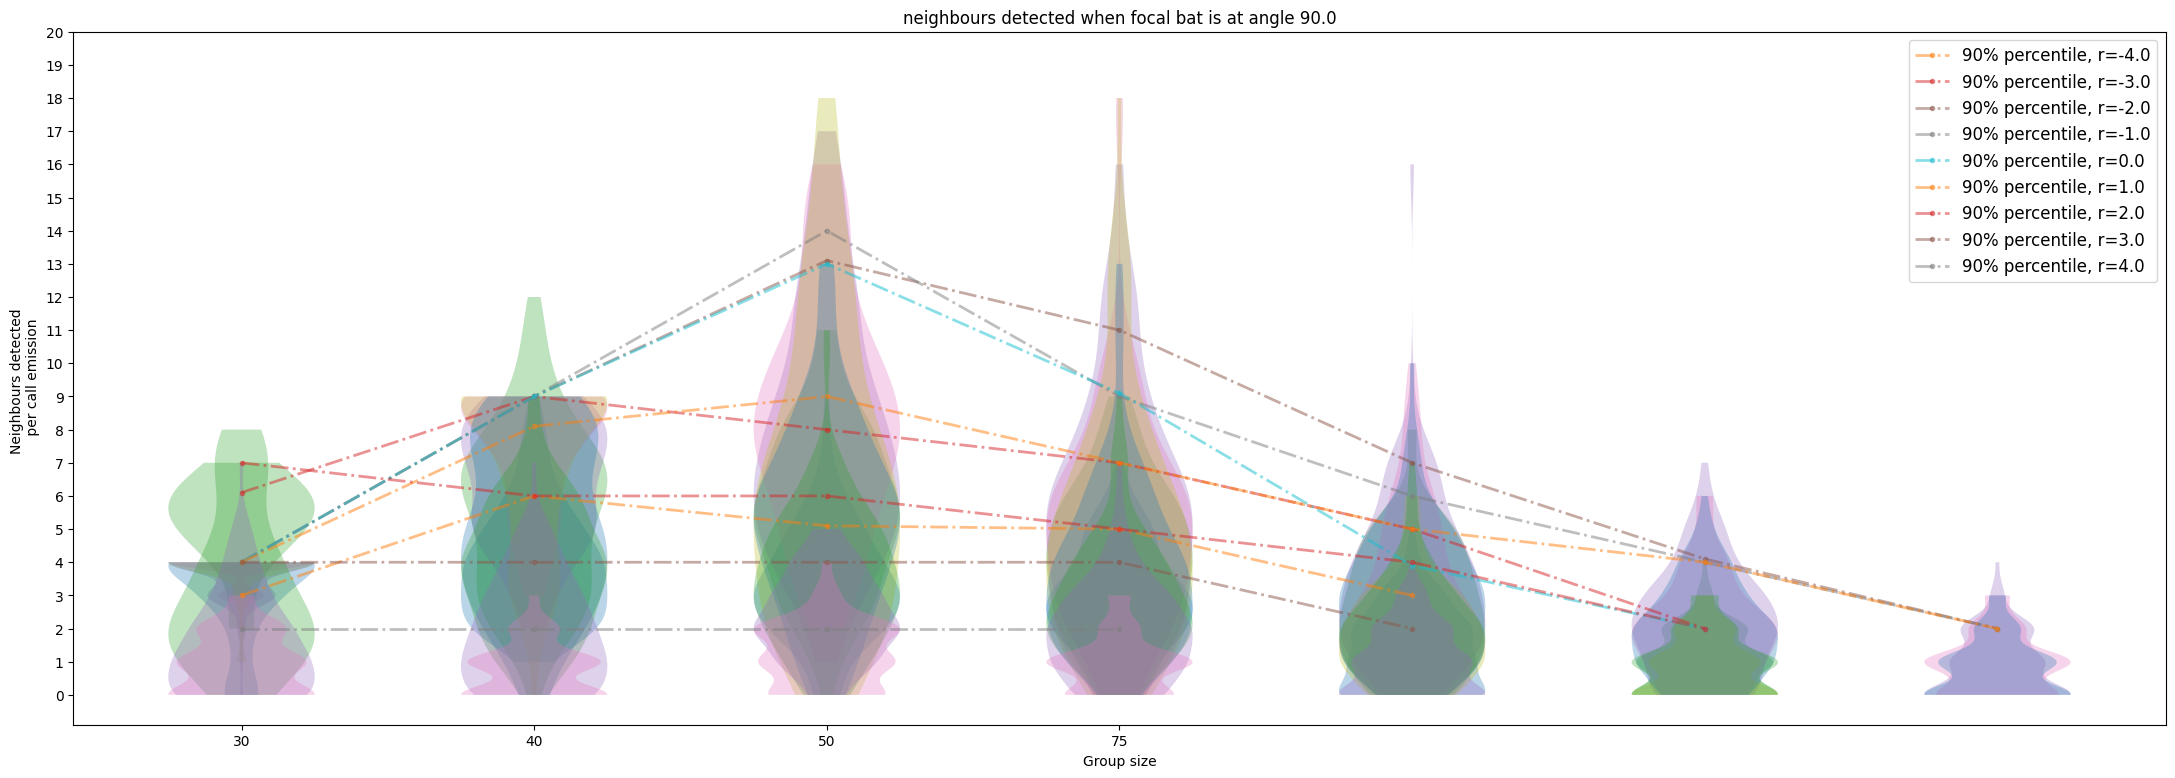

In [ ]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]
sign_based_on_distance_from_centermost_point= [-1, -1, -1, -1, 0, 1, 1, 1, 1]
fig, axs = plt.subplots(1,1, figsize=(27,9))
iterant2_color=0
for simulation_data in sublist_of_simulation_data_intransect:
        data_by_groupsize = simulation_data.groupby(['group_size'])
        nbrs_detected_data = {}
        nbrs_detected_data['num_nbrs'] = []
        nbrs_detected_data['median_num_nbrs'] = []
        nbrs_detected_data['90%ile_num_nbrs'] = []
        groupsizes= []
        for groupsize, dataframe in data_by_groupsize:
                groupsizes.append(groupsize)
                nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

        breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5
        nbrs_detected_data['median_num_nbrs']

        # plt.figure(figsize=(7,3.42))
        # plt.subplot(1,2,i)
        
        axs.violinplot(nbrs_detected_data['num_nbrs'][:], showextrema=False)
        # axs.plot(np.arange(1,len(groupsizes)+1),nbrs_detected_data['median_num_nbrs'][:],
        #         '--*',linewidth=2, alpha=0.5,label="median, r="+str(sign_based_on_distance_from_centermost_point[iterant2_color]*simulation_data["focal_bat"][0][0]), 
        #         color= colors[iterant2_color])#'median')
        # print(np.arange(1,len(groupsizes)))
        axs.plot(np.arange(1,len(groupsizes)+1), nbrs_detected_data['90%ile_num_nbrs'][:],
                '-..',linewidth=2, alpha=0.5, label="90% percentile, r="+str(sign_based_on_distance_from_centermost_point[iterant2_color]*simulation_data["focal_bat"][0][0])
                )#label='90%ile')
        # plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
        axs.set_yticks(np.arange(0,21,1))
        axs.set_xticks(range(1,len(groupsizes)+1),groupsizes[:])
        axs.legend(fontsize=12)
        axs.set_ylabel('Neighbours detected \n per call emission', fontsize=10)
        axs.set_xlabel('Group size', fontsize=10)
        # # plt.ylim(0,20)

        # axs[i].tight_layout()
        axs.set_title("neighbours detected when focal bat is at angle "+str(np.degrees(simulation_data["focal_bat"][0][1])))
        iterant2_color+=1
plt.show()

separate the violin plots out for different group sizes to see clear differences between distance from center


ValueError: zero-size array to reduction operation minimum which has no identity

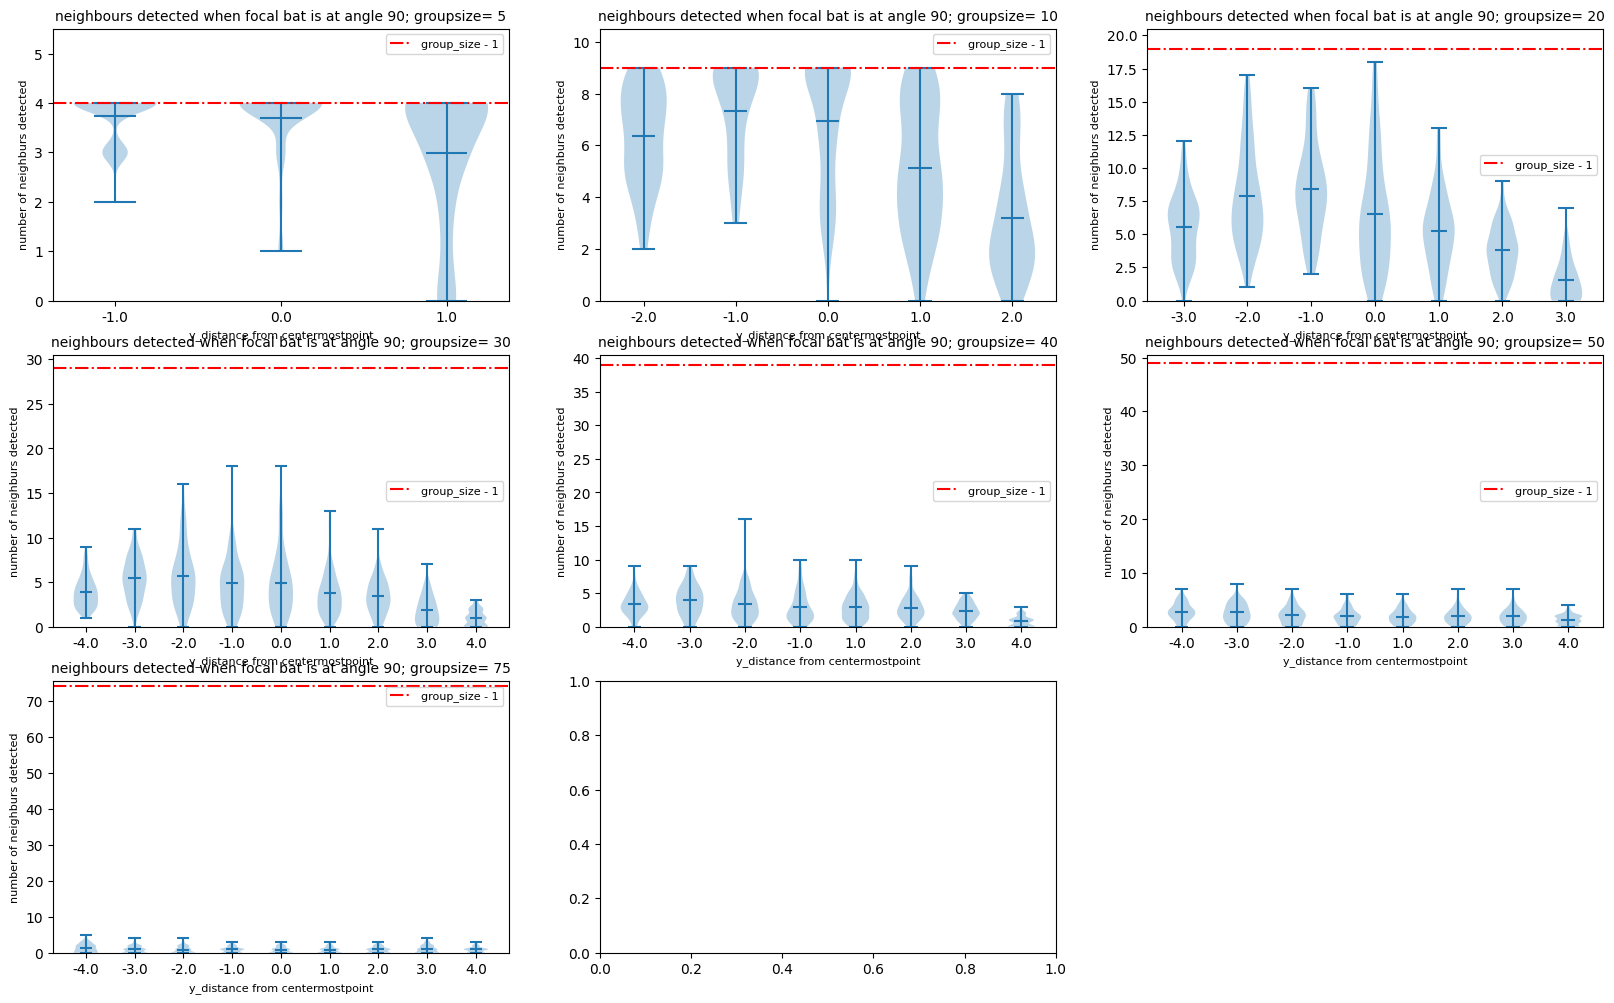

In [ ]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]
sign_based_on_distance_from_centermost_point= [-1, -1, -1, -1, 0, 1, 1, 1, 1]

group_sizes= [5,10,20,30,40,50,75,100]

# fig, axs = plt.subplots(1,1, figsize=(27,9))
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize=(20,12))
for group_size in group_sizes:
    nbrs_detected_data = {}
    nbrs_detected_data['num_nbrs'] = []
    nbrs_detected_data['median_num_nbrs'] = []
    nbrs_detected_data['90%ile_num_nbrs'] = []
    
    x_ticks= []; iterant_sign=-1
    for simulation_data in sublist_of_simulation_data_intransect:
        iterant_sign+=1

        try:
            dataframe = simulation_data.groupby(['group_size']).get_group(group_size)    
            if len(dataframe["nbrs_detected"])!=100:
                continue
            nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
            nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
            nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))    
        except KeyError:
            continue
        x_ticks.append(sign_based_on_distance_from_centermost_point[iterant_sign]*simulation_data["focal_bat"][0][0])
    

    plt.subplot(number_of_rows,number_of_columns,i+1)
    plt.violinplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    # plt.boxplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    plt.title(f"neighbours detected when focal bat is at angle {90}; groupsize= {group_size}", fontsize= "10")
    plt.xticks(np.arange(1,len(x_ticks)+1),x_ticks)
    # plt.show()
    plt.ylim(0,group_size+0.5)
    plt.axhline(group_size-1, ls="-.", color="red", label= "group_size - 1")
    plt.xlabel("y_distance from centermostpoint", fontsize= "8")
    plt.ylabel("number of neighburs detected", fontsize= "8")
    plt.legend(fontsize= "8")

    i+=1

Zooming into the plots to see finer differences between the diffrent violin plots

ValueError: zero-size array to reduction operation minimum which has no identity

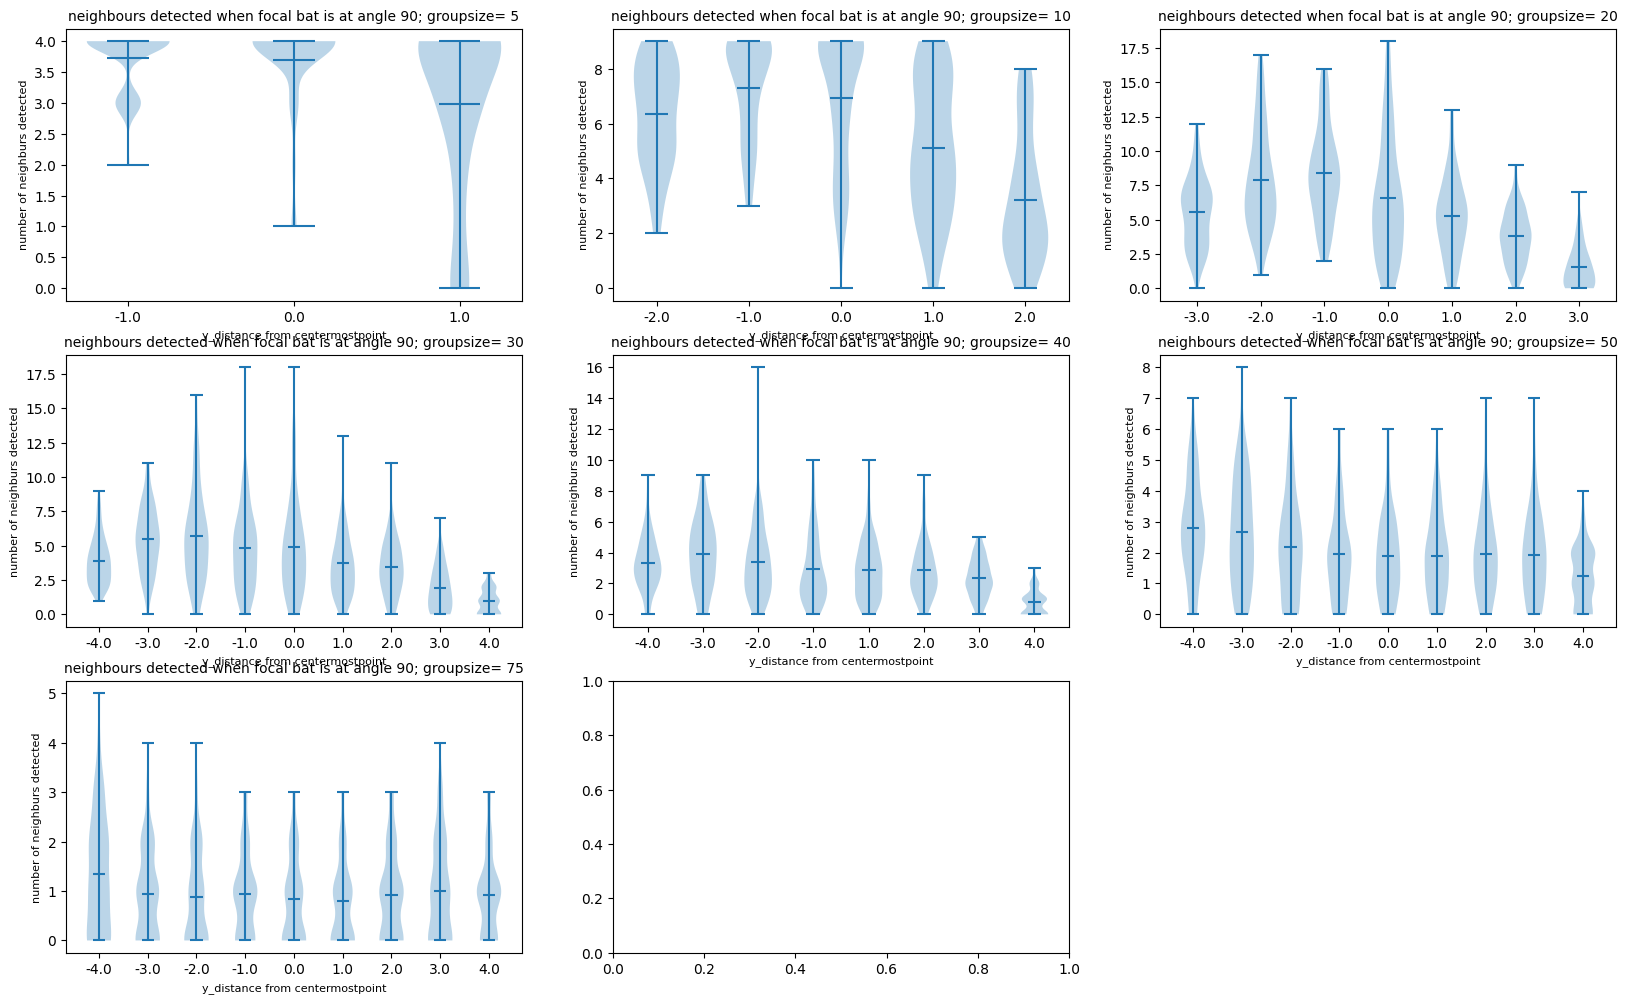

In [ ]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]
sign_based_on_distance_from_centermost_point= [-1, -1, -1, -1,0, 1, 1, 1, 1]

group_sizes= [5,10,20,30,40,50,75,100]

# fig, axs = plt.subplots(1,1, figsize=(27,9))
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize=(20,12))
for group_size in group_sizes:
    nbrs_detected_data = {}
    nbrs_detected_data['num_nbrs'] = []
    nbrs_detected_data['median_num_nbrs'] = []
    nbrs_detected_data['90%ile_num_nbrs'] = []
    
    x_ticks= []; iterant_sign=-1
    for simulation_data in sublist_of_simulation_data_intransect:
        iterant_sign+=1
        try:
            dataframe = simulation_data.groupby(['group_size']).get_group(group_size)    
            if len(dataframe["nbrs_detected"])<90:
                continue
            nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
            nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
            nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))    
        except KeyError:
            continue
        x_ticks.append(sign_based_on_distance_from_centermost_point[iterant_sign]*simulation_data["focal_bat"][0][0])

        

    plt.subplot(number_of_rows,number_of_columns,i+1)
    plt.violinplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    # plt.boxplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    plt.title(f"neighbours detected when focal bat is at angle {90}; groupsize= {group_size}", fontsize= "10")
    plt.xticks(np.arange(1,len(x_ticks)+1),x_ticks)
    # plt.show()
    # plt.ylim(0,group_size+0.5)
    # plt.axhline(group_size-1, ls="-.", color="red", label= "group_size - 1")
    plt.xlabel("y_distance from centermostpoint", fontsize= "8")
    plt.ylabel("number of neighburs detected", fontsize= "8")
    # plt.legend(fontsize= "8")

    i+=1

The number of neighbours detected shows an increase with group size initially and then drops sharply down beyond 30 bats. 


### How does the probability of detecting at least one neighbour change with group size?

In [ ]:
def calculate_geqNneighbour(num_detected_neighbours, N):
    '''Calculates the proportion of an array-like
    object that is >= N.
    
    '''
    geq_N = np.float64(np.sum(num_detected_neighbours>=N))
    if np.isnan(np.min(num_detected_neighbours)):
        return np.nan
    proportion_geq_N = geq_N/len(num_detected_neighbours)
    return(proportion_geq_N)

In [ ]:
#store data
store_probability_of_detection_n_neighbour= {}
sign_based_on_distance_from_centermost_point= [-1, -1, -1, -1, 0, 1, 1, 1, 1]
group_sizes= [5,10,20,30,40,50,75,100]
i=0
for simulation_data in sublist_of_simulation_data_intransect:
        data_by_groupsize = simulation_data.groupby(['group_size'])

        nbrs_detected_data = {}
        nbrs_detected_data['num_nbrs'] = []
        nbrs_detected_data['median_num_nbrs'] = []
        nbrs_detected_data['90%ile_num_nbrs'] = []
        groupsizes= []

        for groupsize, dataframe in data_by_groupsize:
                groupsizes.append(groupsize)
                nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))
        nan_groupsizes= [i for i in group_sizes if i not in groupsizes]
        for nan_groupsize in nan_groupsizes:
                nbrs_detected_data['num_nbrs']= [np.nan, *nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['median_num_nbrs']= [np.nan, *nbrs_detected_data['median_num_nbrs']]
                nbrs_detected_data['90%ile_num_nbrs']= [np.nan, *nbrs_detected_data['90%ile_num_nbrs']]

        nbrs_detected_data['0neighbours'] = [ 1-calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_1neighbour'] = [ calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_2neighbour'] = [ calculate_geqNneighbour(each,2)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_3neighbour'] = [ calculate_geqNneighbour(each,3)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_4neighbour'] = [ calculate_geqNneighbour(each,4)  for each in nbrs_detected_data['num_nbrs']]

        nbrs_detected_data['detected_distances'] = [ np.concatenate(np.array(dataframe['nbrs_detected_distance'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_detected_distances'] = map(np.median, nbrs_detected_data['detected_distances'])
        nbrs_detected_data['90%ile_detected_distances'] = map(lambda X : np.percentile(X,90),
                                                        nbrs_detected_data['detected_distances'][:-1])

        nbrs_detected_data['neighbours_azimuth'] = [ np.concatenate(np.array(dataframe['detection_azimuth'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_neighbours_azimuth'] = [ np.median(each)  for each in nbrs_detected_data['neighbours_azimuth'] ]
        nbrs_detected_data['95%ile_neighbours_azimuth'] = [ np.percentile(each, 92.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]
        nbrs_detected_data['5%ile_neighbours_azimuth'] = [ np.percentile(each, 2.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]

        nbrs_detected_data['echolevels'] = [ np.concatenate(np.array(dataframe['echo_levels'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_echolevels'] = [ np.median(each) for each in nbrs_detected_data['echolevels']]
        nbrs_detected_data['5%ile_echolevels'] = [ np.percentile(each, 2.5) for each in nbrs_detected_data['echolevels'][:-1]]
        nbrs_detected_data['95%ile_echolevels'] = [ np.percentile(each, 97.5) for each in nbrs_detected_data['echolevels'][:-1]]

        for nan_groupsize in nan_groupsizes:
                nbrs_detected_data['detected_distances']= [np.nan, *nbrs_detected_data['detected_distances']]
                nbrs_detected_data['median_detected_distances']= [np.nan, *nbrs_detected_data['median_detected_distances']]
                nbrs_detected_data['90%ile_detected_distances']= [np.nan, *nbrs_detected_data['90%ile_detected_distances']]

                nbrs_detected_data['neighbours_azimuth']= [[np.nan], *nbrs_detected_data['neighbours_azimuth']]
                nbrs_detected_data['median_neighbours_azimuth']= [np.nan, *nbrs_detected_data['median_neighbours_azimuth']]
                nbrs_detected_data['5%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['5%ile_neighbours_azimuth']]
                nbrs_detected_data['95%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['95%ile_neighbours_azimuth']]

                nbrs_detected_data['echolevels']= [[np.nan], *nbrs_detected_data['echolevels']]
                nbrs_detected_data['median_echolevels']= [np.nan, *nbrs_detected_data['median_echolevels']]
                nbrs_detected_data['5%ile_echolevels']= [np.nan, *nbrs_detected_data['5%ile_echolevels']]
                nbrs_detected_data['95%ile_echolevels']= [np.nan, *nbrs_detected_data['95%ile_echolevels']]
                
        
        store_probability_of_detection_n_neighbour[simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]]= nbrs_detected_data
        i+=1

/tmp/ipykernel_41993/3502998447.py:15: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_41993/3502998447.py:32: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  nbrs_detected_data['detected_distances'] = [ np.concatenate(np.array(dataframe['nbrs_detected_distance'])) for groupsize, dataframe in data_by_groupsize]
/tmp/ipykernel_41993/3502998447.py:37: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  nbrs_detected_data[

[42, nan, 2, 1, 0]


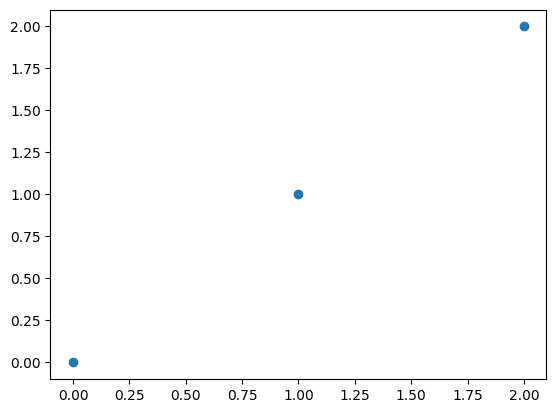

In [ ]:
x= [np.nan,2,1,0]
x2=[42, *x]
print(x2)
plt.scatter(x,x)

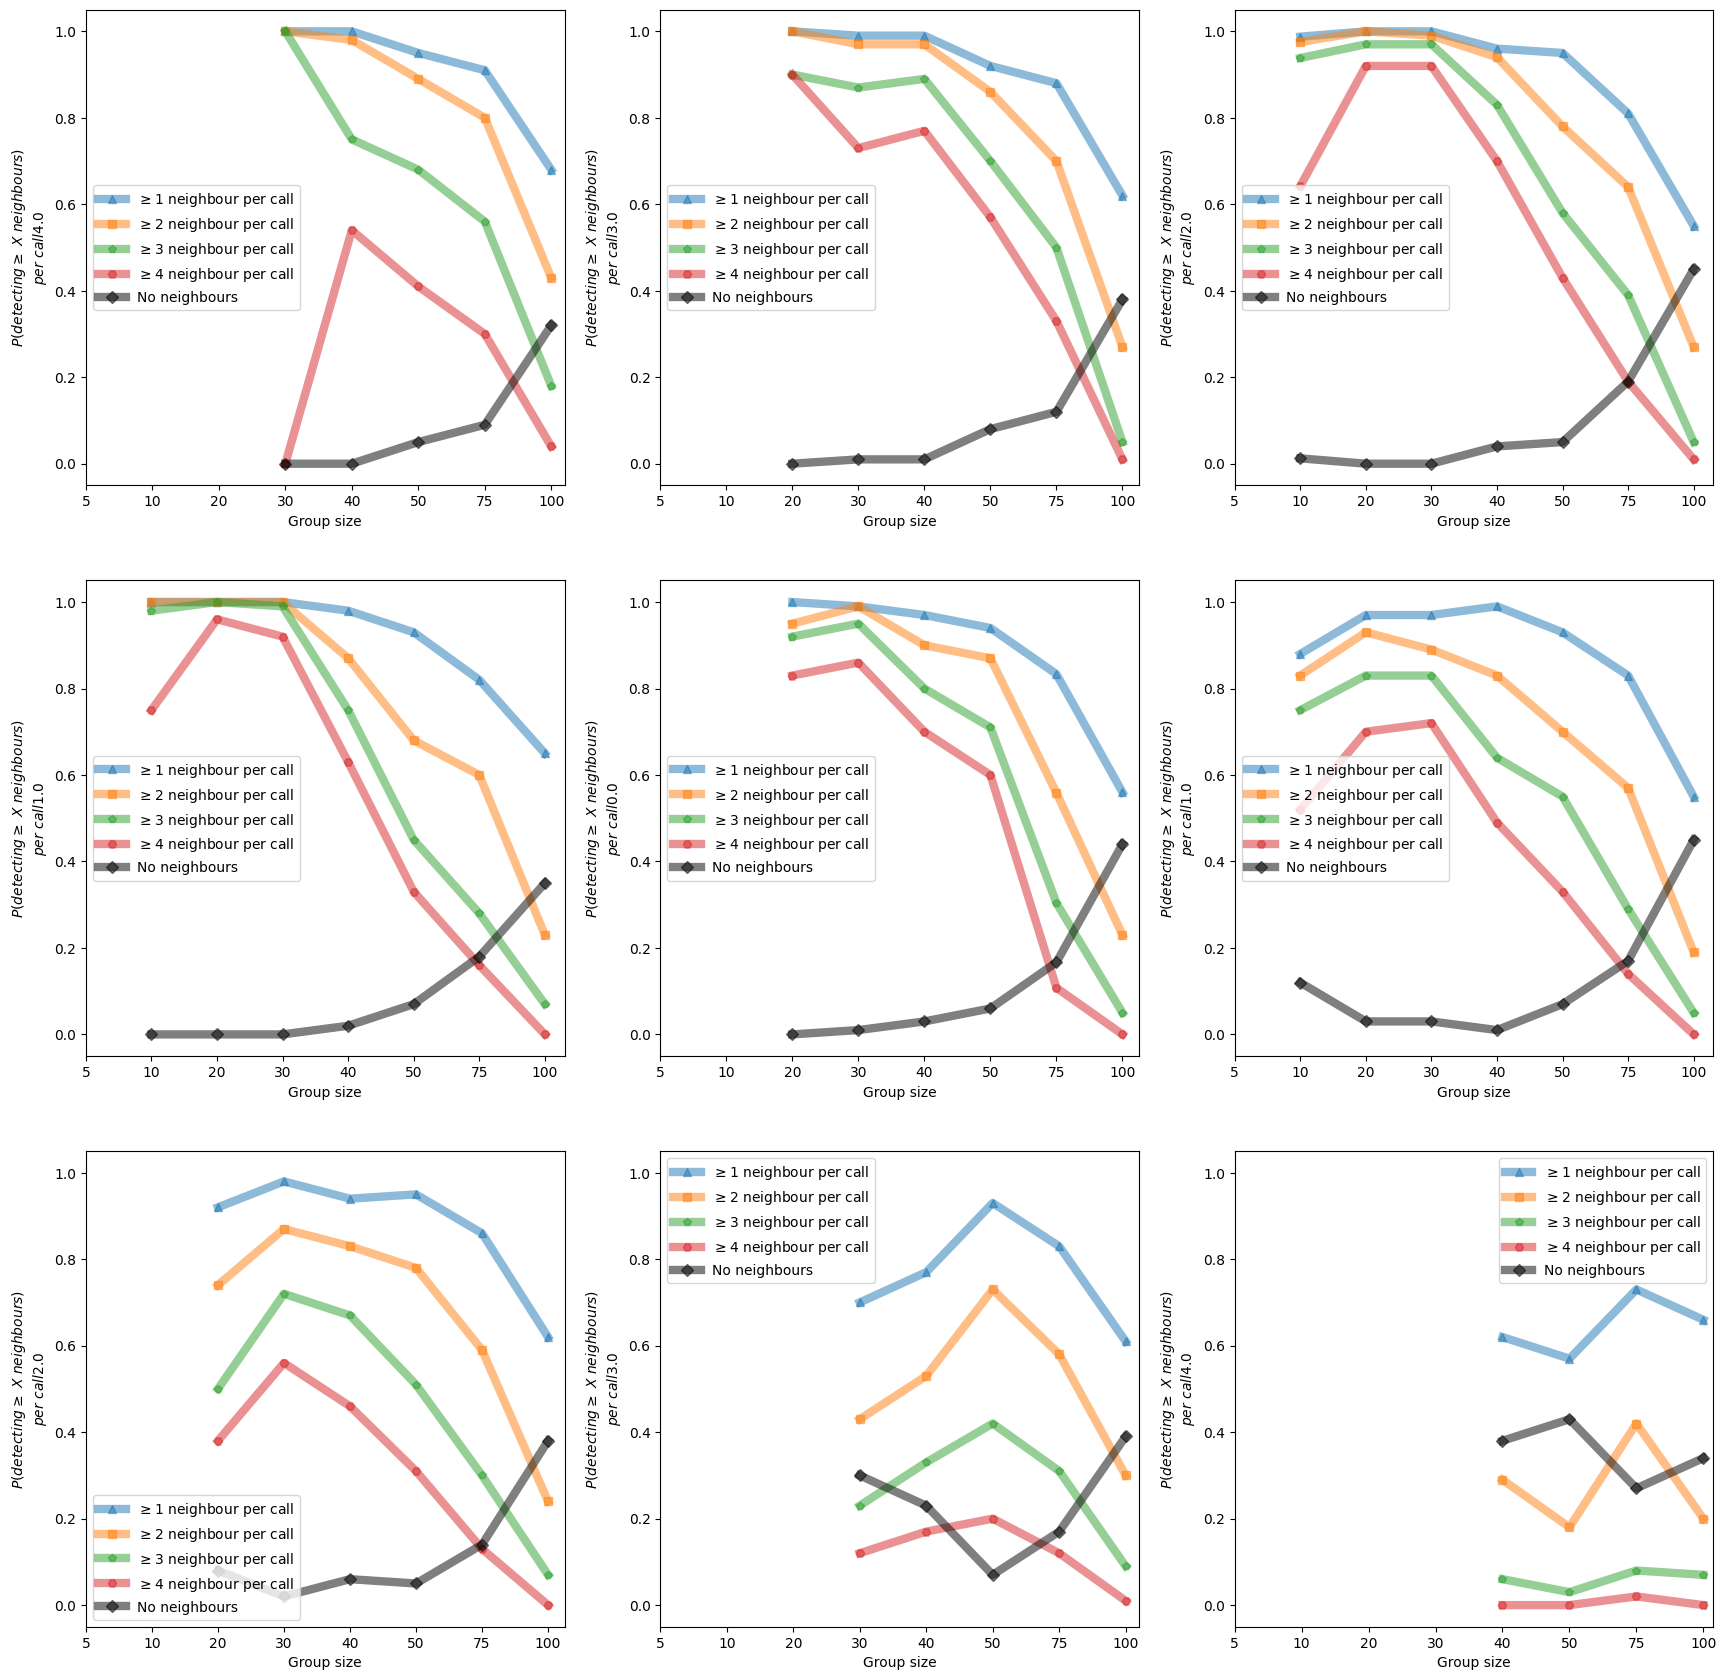

In [ ]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]
sign_based_on_distance_from_centermost_point= [-1, -1, -1, -1, 0, 1, 1, 1, 1]
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize= (21,21))
for simulation_data in sublist_of_simulation_data_intransect:
        data_by_groupsize = simulation_data.groupby(['group_size'])
        groupsizes= group_sizes

        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_1neighbour'], '-^', linewidth=6, alpha=0.5, label='$\geq1$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_2neighbour'], '-s', linewidth=6, alpha=0.5, label='$\geq2$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_3neighbour'], '-p', linewidth=6, alpha=0.5, label='$\geq3$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_4neighbour'], '-H', linewidth=6, alpha=0.5, label='$\geq4$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['0neighbours'], '-Dk', linewidth=6, alpha=0.5, label='No neighbours')

        plt.yticks(fontsize=10)
        plt.xticks(np.arange(1,len(groupsizes)+1),
                groupsizes,fontsize=10)
        plt.legend()
        plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$'+str(simulation_data["focal_bat"][0][0]),
                fontsize=10)
        plt.xlabel('Group size',
                fontsize=10)
        plt.ylim(-0.05,1.05)
        
        i+=1

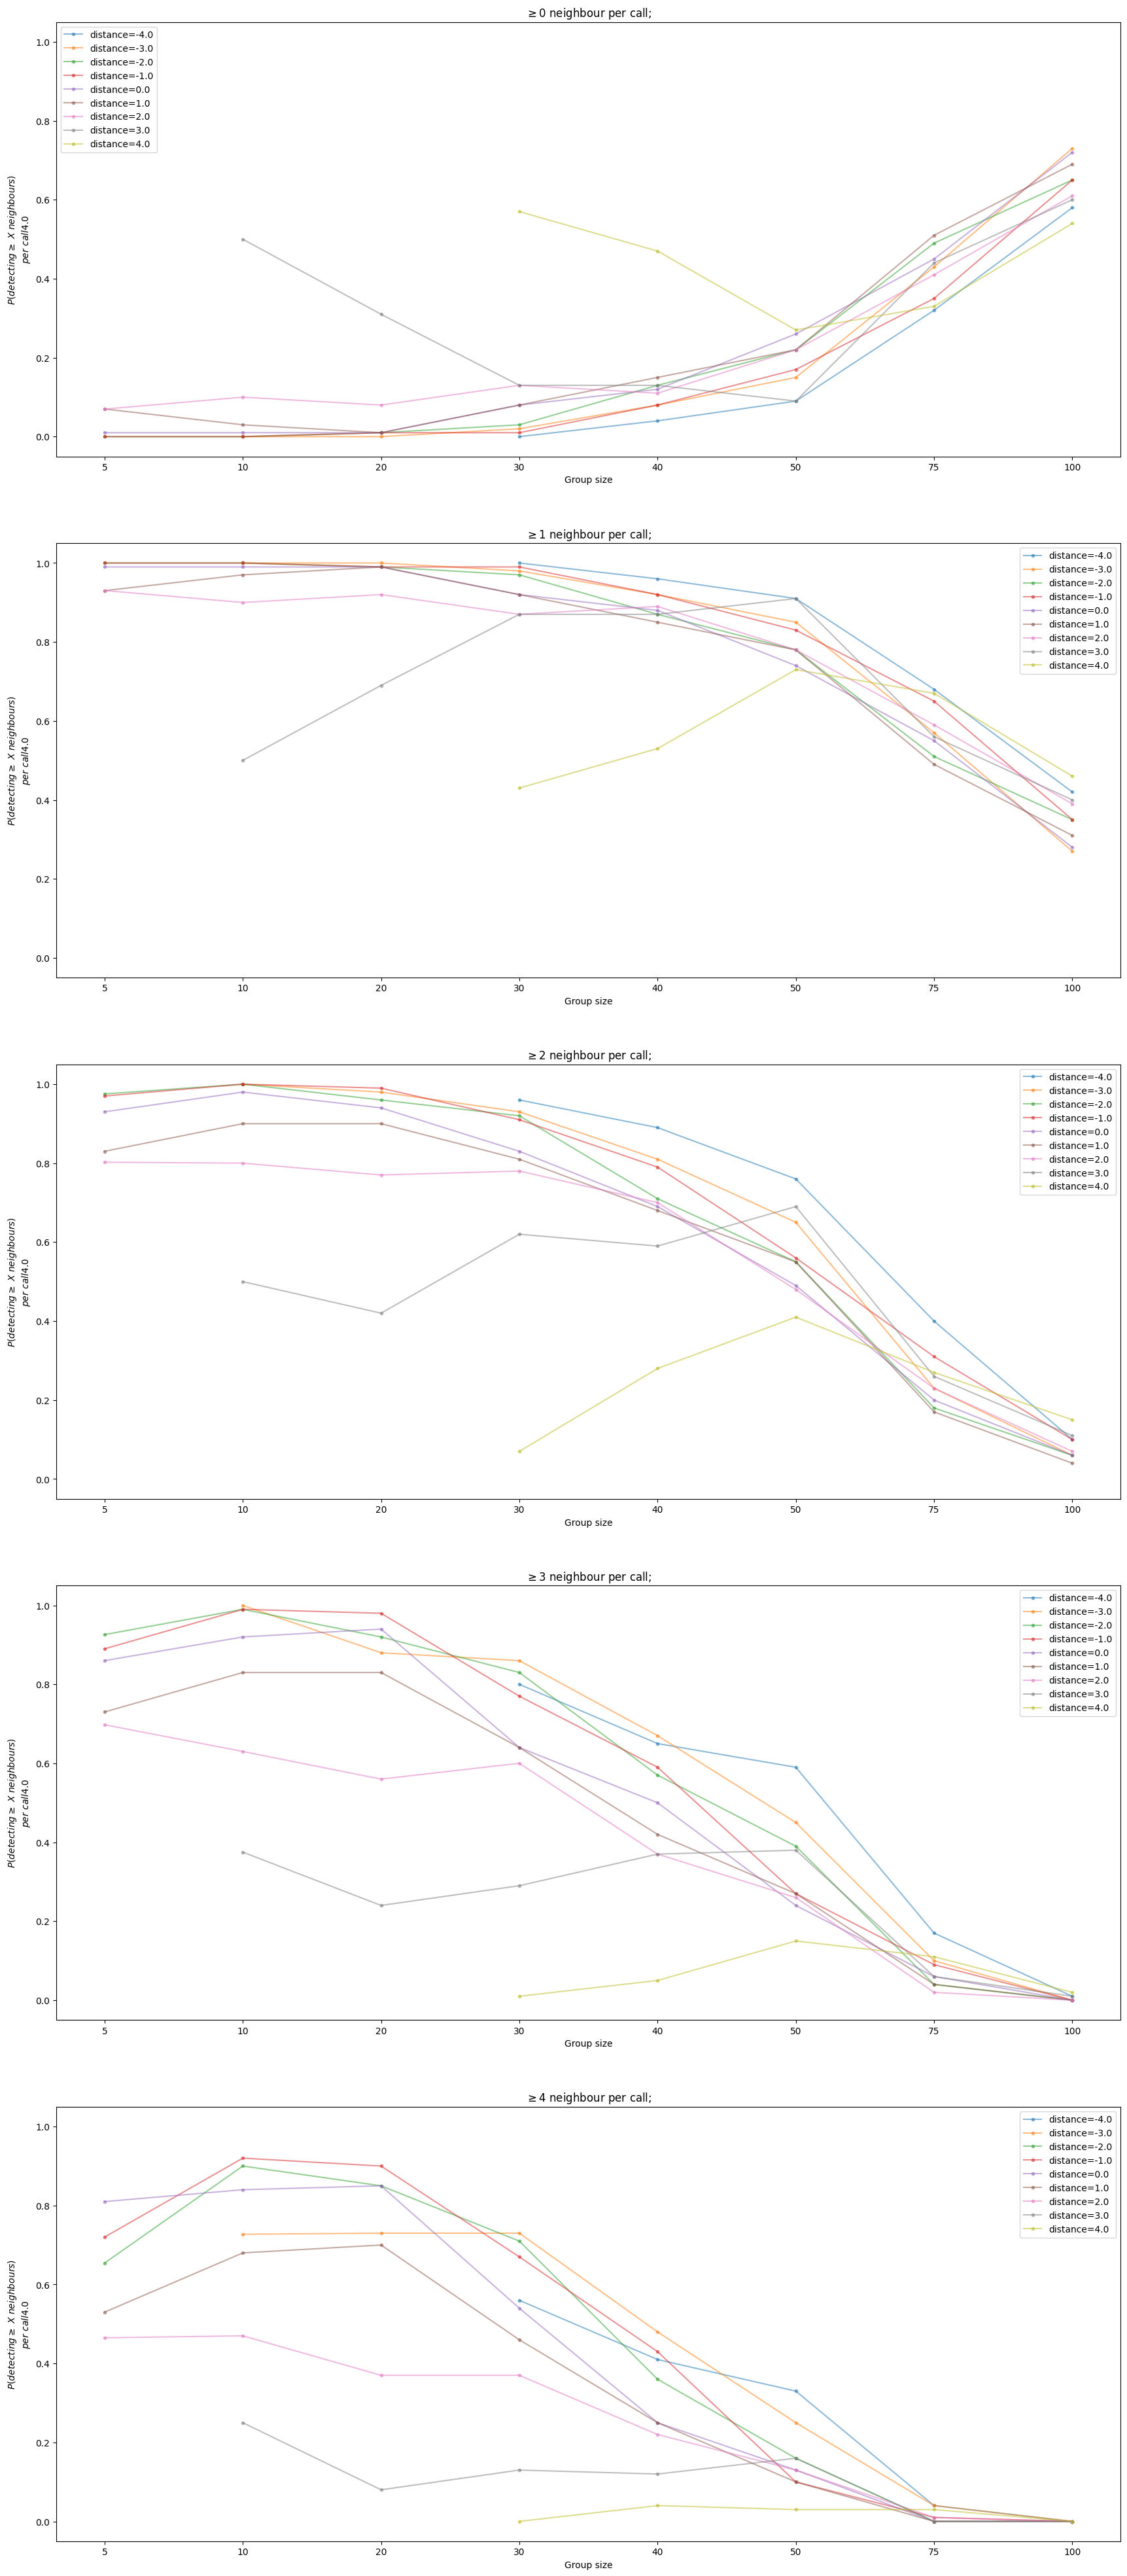

In [ ]:
number_of_neighbours_atleast_detected= [0,1,2,3,4]
sign_based_on_distance_from_centermost_point= [-1, -1, -1, -1, 0, 1, 1, 1, 1]
i=0; 
number_of_columns=1; number_of_rows= int(np.ceil(len(number_of_neighbours_atleast_detected)/number_of_columns))
plt.figure(figsize= (21,50))

for simulation_data in sublist_of_simulation_data_intransect:

        groupsizes= group_sizes

        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,2)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_1neighbour'], '.-', alpha=0.5, label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,3)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_2neighbour'], '.-', alpha=0.5, label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,4)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_3neighbour'], '.-', alpha=0.5, label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,5)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_4neighbour'], '.-', alpha=0.5, label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,1)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['0neighbours'], '.-', alpha=0.5, label=f'distance={key_for_dict}')
        i+=1
for i in range(1,6):
        plt.subplot(number_of_rows,number_of_columns,i)
        plt.yticks(fontsize=10)
        plt.xticks(np.arange(1,len(groupsizes)+1),
                groupsizes,fontsize=10)
        plt.legend()
        plt.title(f"$\geq{i-1}$ neighbour per call;")
        plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$'+str(simulation_data["focal_bat"][0][0]),
                fontsize=10)
        plt.xlabel('Group size',
                fontsize=10)
        plt.ylim(-0.05,1.05)


-4.0
-3.0
-2.0
-1.0
0.0
1.0
2.0
3.0
4.0


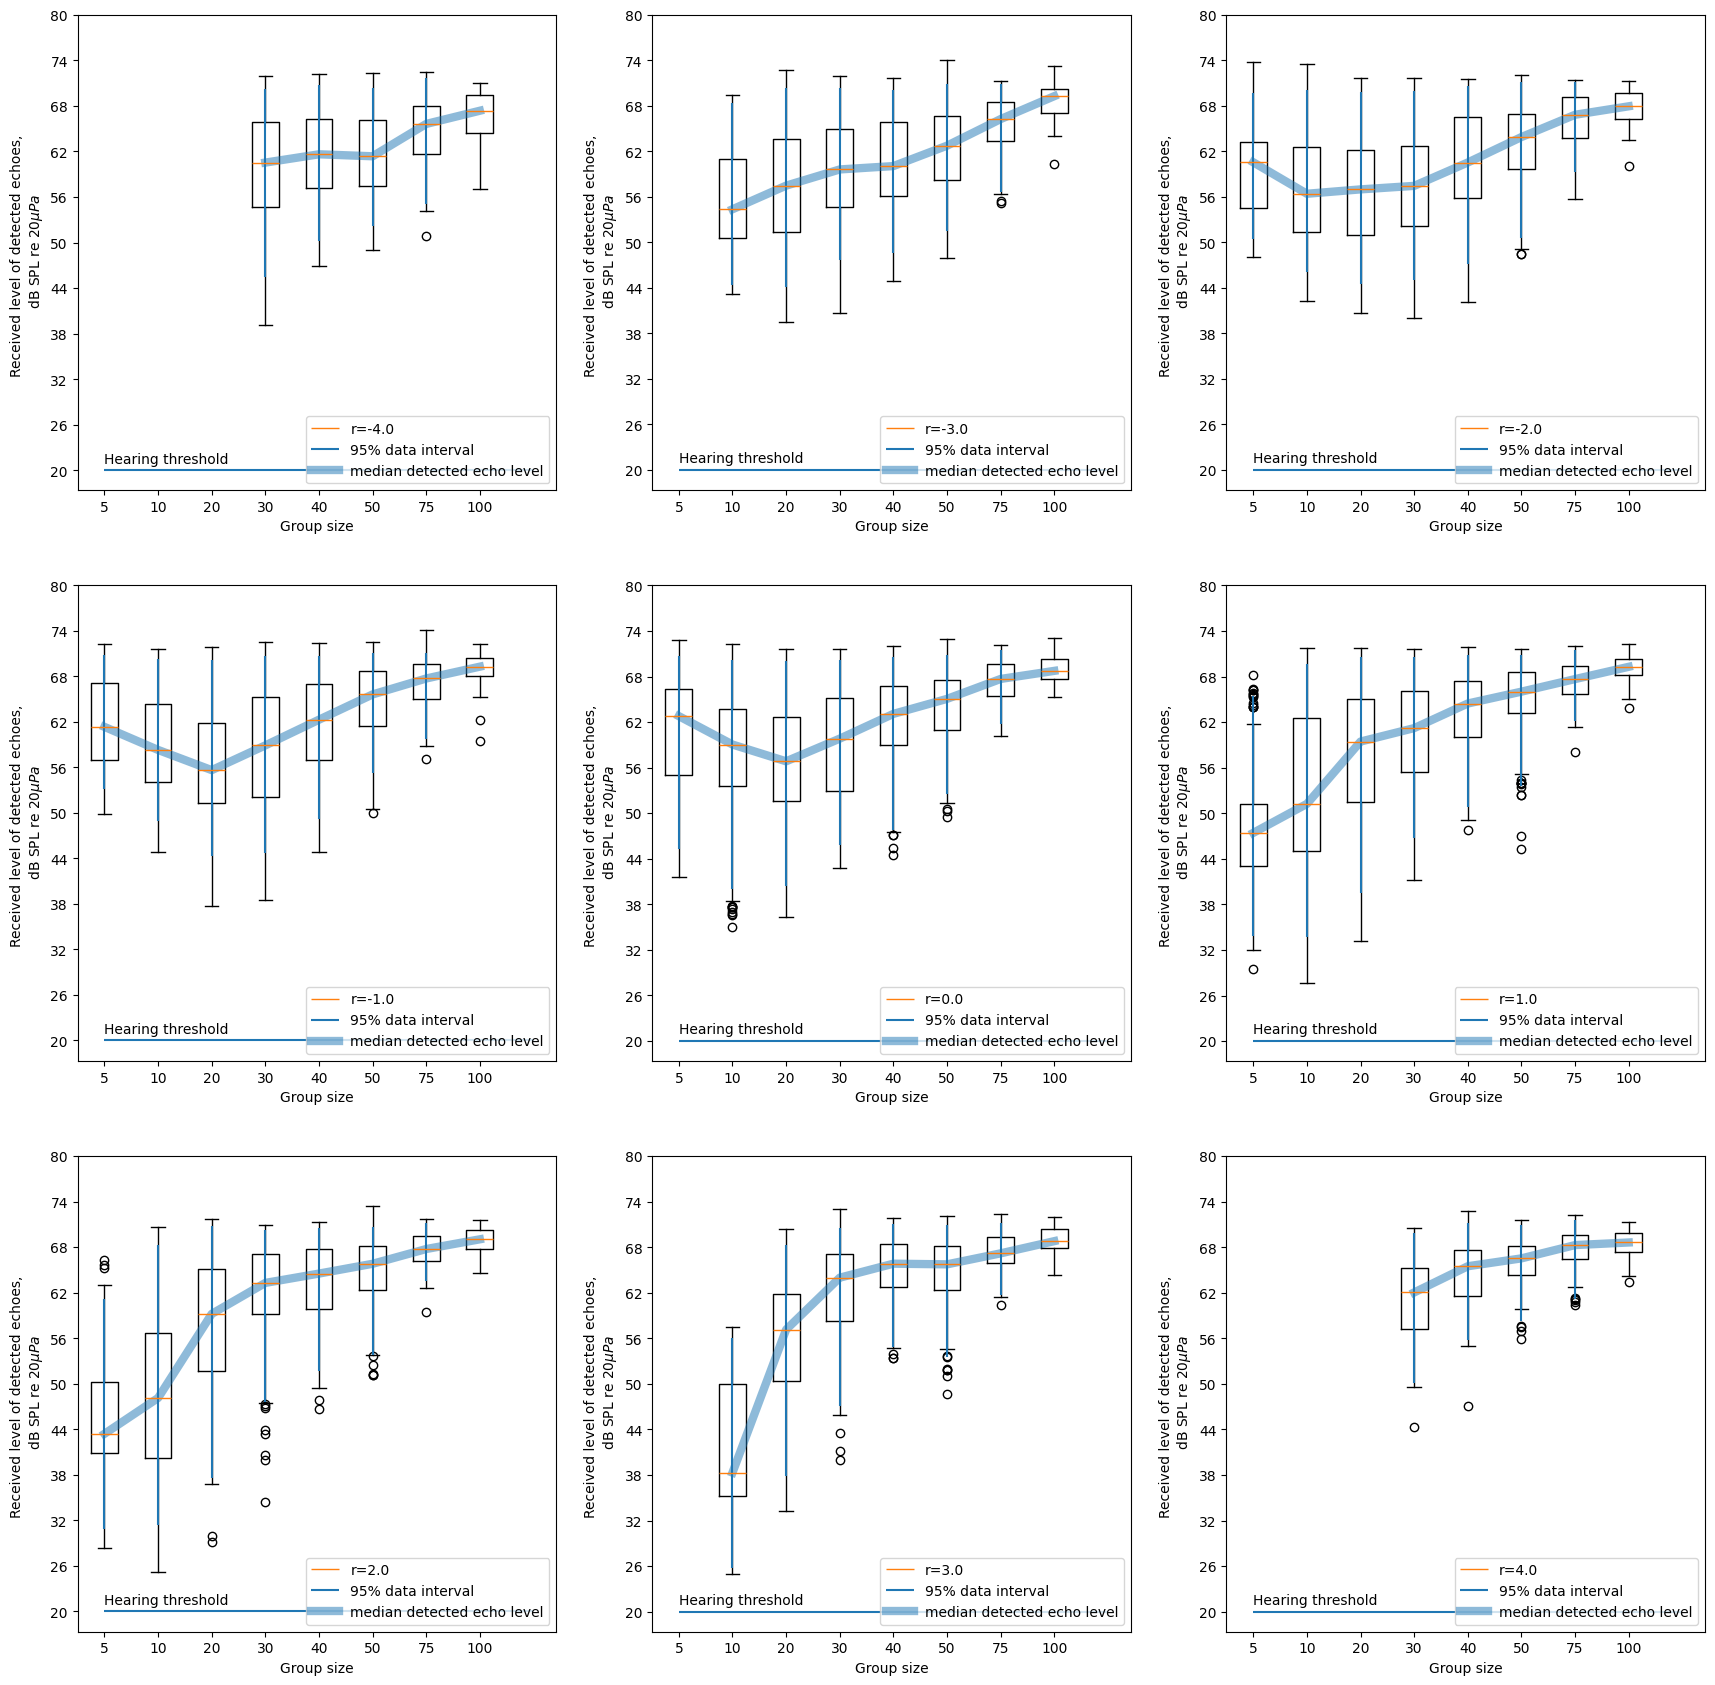

In [ ]:

i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize= (21,21))
for simulation_data in sublist_of_simulation_data_intransect:
        groupsizes= group_sizes
        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(nbrs_detected_data['echolevels'][:], label=f"r={key_for_dict}");
        plt.vlines(range(1,len(nbrs_detected_data['95%ile_echolevels'])+1),nbrs_detected_data['5%ile_echolevels'],
                                                                        nbrs_detected_data['95%ile_echolevels'],
                                label='95% data interval')

        plt.plot(range(1,len(groupsizes)+1), nbrs_detected_data['median_echolevels'], linewidth=6, alpha=0.5,
                label='median detected echo level')
        plt.ylabel('Received level of detected echoes, \n dB SPL re 20$\mu Pa$',
                                                fontsize=10)
        plt.xticks(np.arange(1,len(groupsizes)+1), groupsizes, fontsize=10)
        plt.hlines([20],1,len(groupsizes)+1)
        plt.yticks(np.arange(20,86,6),np.arange(20,86,6), fontsize=10)
        plt.text(1,21,'Hearing threshold', fontsize=10)
        plt.xlabel('Group size', fontsize=10)
        plt.legend()
        print(key_for_dict)
        i+=1

In [ ]:
group_sizes

[5, 10, 20, 30, 40, 50, 75, 100]

/tmp/ipykernel_41993/145434650.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_41993/145434650.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_41993/145434650.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_41993/145434650.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_41993/145434650.py:26: UserWarning: No artists with labels found to put in legend.  Note that

4.0
4.0
4.0
4.0
4.0
4.0
4.0
4.0


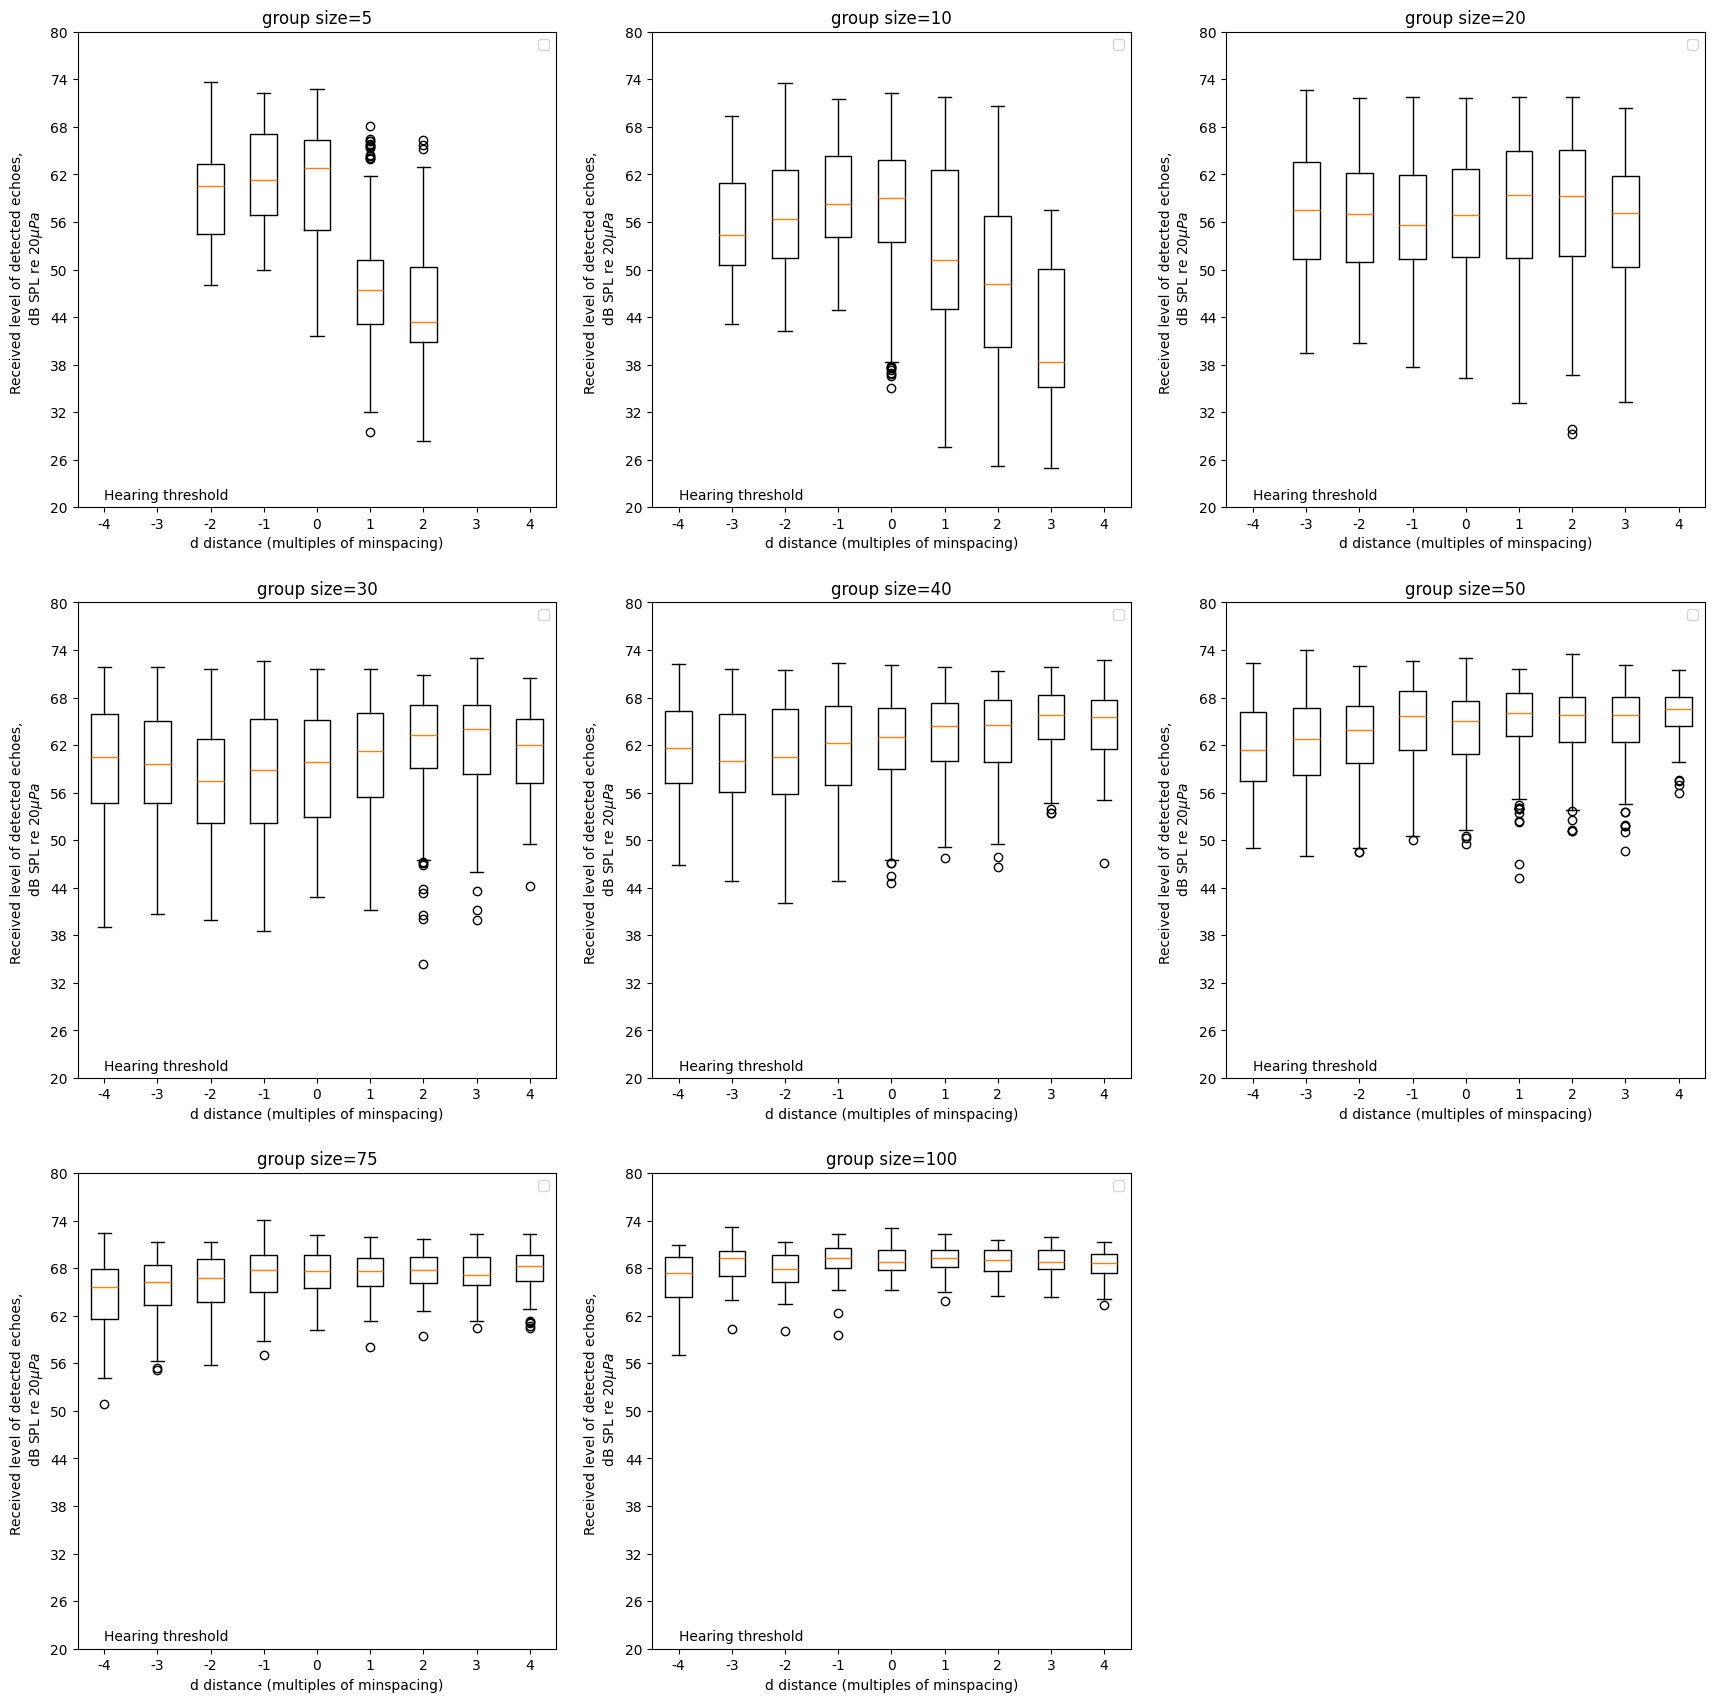

In [ ]:
i=0; 
d_distances_along_transect= np.arange(-4,5,1)
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize= (21,21))
group_sizes = [5, 10, 20, 30, 40, 50, 75, 100]
for group_size in group_sizes:
        array_storing_info_for_plot= []
        iterant_sign=-1
        x_ticks=[]
        for key in d_distances_along_transect:
                iterant_sign+=1
                nbrs_detected_data= store_probability_of_detection_n_neighbour[key]
                data_to_store= nbrs_detected_data['echolevels'][group_sizes.index(group_size)]
                array_storing_info_for_plot.append(data_to_store)
                x_ticks.append(key)

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(array_storing_info_for_plot);

        plt.ylabel('Received level of detected echoes, \n dB SPL re 20$\mu Pa$',
                                                fontsize=10)
        plt.xticks(np.arange(1,len(x_ticks)+1), x_ticks, fontsize=10)
        plt.yticks(np.arange(20,86,6),np.arange(20,86,6), fontsize=10)
        plt.text(1,21,'Hearing threshold', fontsize=10)
        plt.xlabel('d distance (multiples of minspacing)', fontsize=10)
        plt.legend()
        plt.title(f"group size={group_size}")
        print(key_for_dict)
        i+=1

-4.0
-3.0
-2.0
-1.0
0.0
1.0
2.0
3.0
4.0


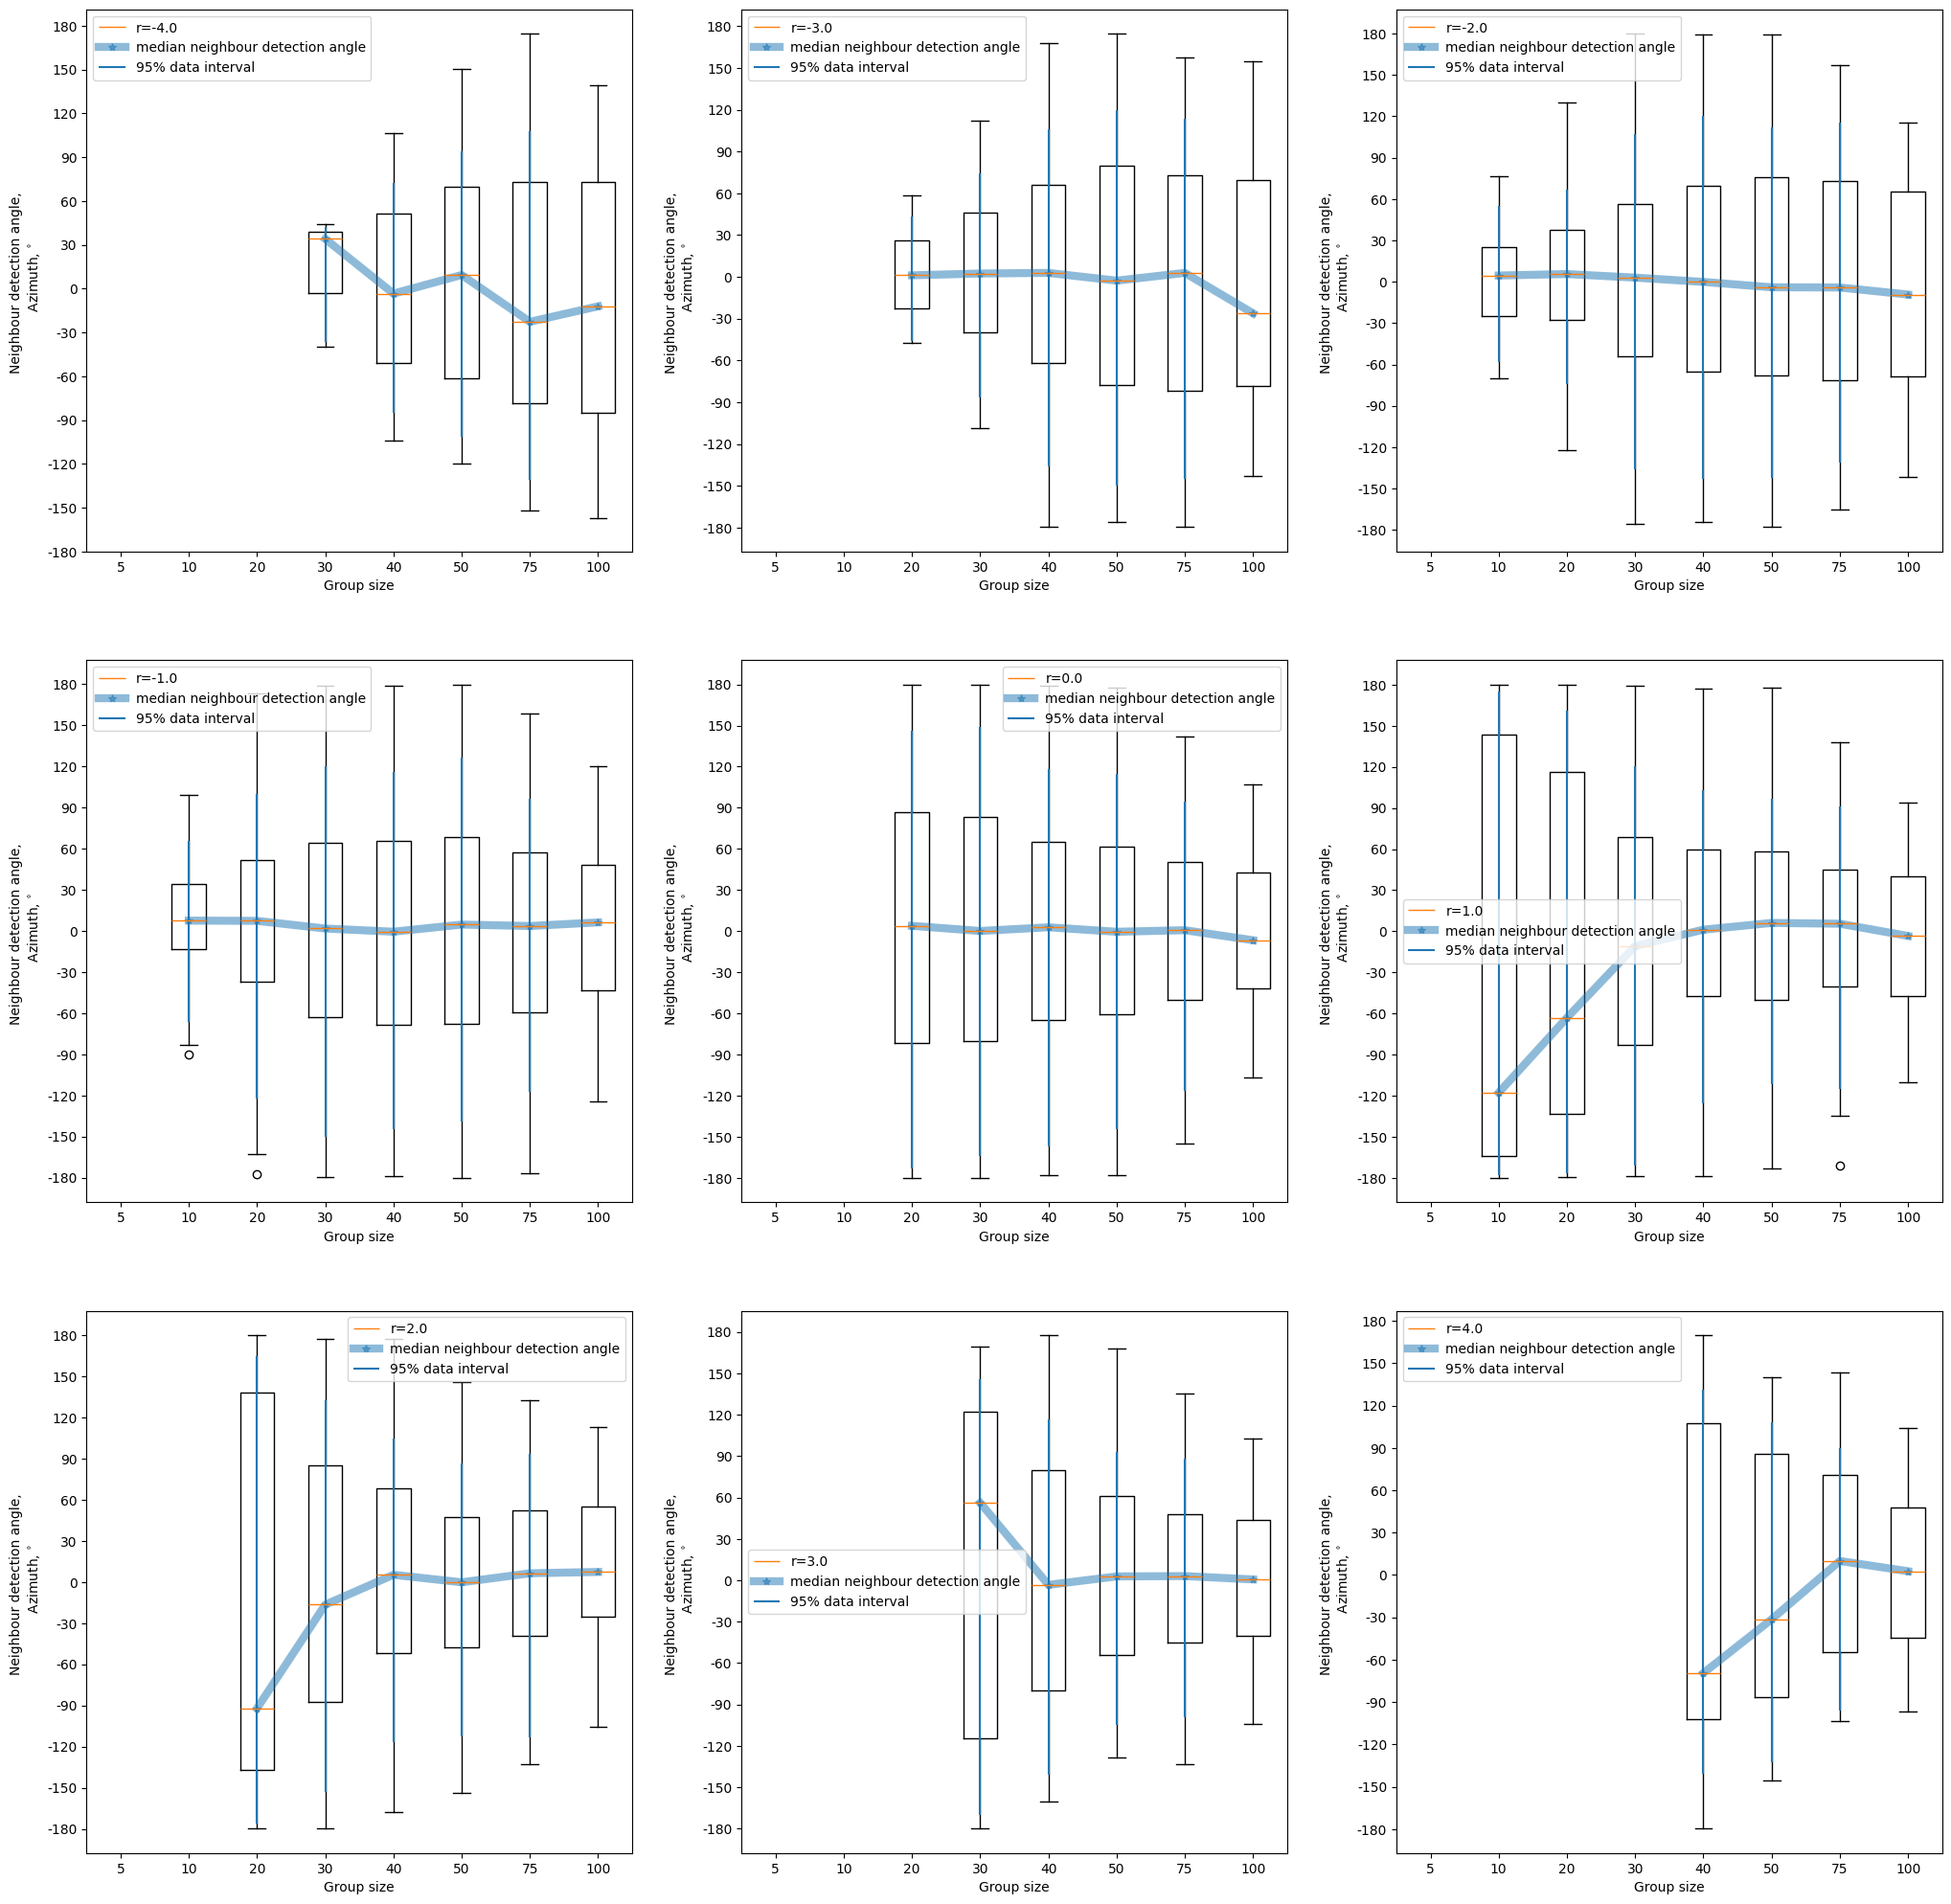

In [ ]:
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize= (25,25))
for simulation_data in sublist_of_simulation_data_intransect:
        groupsizes= group_sizes
        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(nbrs_detected_data['neighbours_azimuth'][:], label=f"r={key_for_dict}")
        plt.plot(np.arange(1,9), nbrs_detected_data['median_neighbours_azimuth'], '-*', linewidth=6,
                        alpha=0.5, label='median neighbour detection angle')
        plt.vlines(range(1,len(nbrs_detected_data['5%ile_neighbours_azimuth'])+1),nbrs_detected_data['5%ile_neighbours_azimuth'],
                nbrs_detected_data['95%ile_neighbours_azimuth'], label='95% data interval')
        #plt.plot(np.arange(1,8), nbrs_detected_data['95%ile_neighbours_azimuth'], 'g')
        #plt.plot(np.arange(1,8), nbrs_detected_data['5%ile_neighbours_azimuth'], 'g', label='95%  neighbour detection range')

        plt.yticks(np.arange(-180,210,30), np.arange(-180,210,30), fontsize=10)
        plt.xticks(np.arange(1,9), groupsizes, fontsize=10)
        plt.legend()
        plt.ylabel('Neighbour detection angle, \n  Azimuth, $^{\circ}$', fontsize=10)
        plt.xlabel('Group size', fontsize=10)


        print(key_for_dict)
        i+=1

192.0


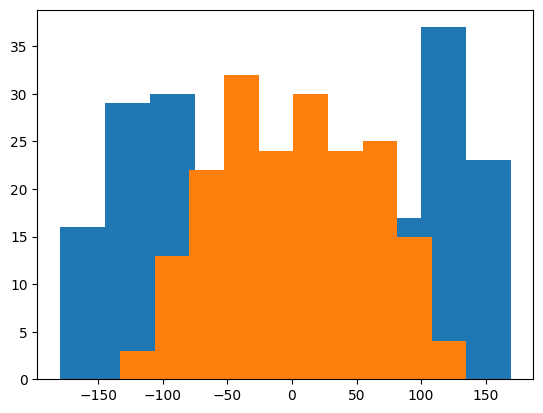

In [ ]:
nbrs_detected_data= store_probability_of_detection_n_neighbour[3]
plt.hist(nbrs_detected_data['neighbours_azimuth'][3])
print(np.sum(plt.hist(nbrs_detected_data['neighbours_azimuth'][6])[0]))

/tmp/ipykernel_41993/4101539089.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_41993/4101539089.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_41993/4101539089.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_41993/4101539089.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_41993/4101539089.py:25: UserWarning: No artists with labels found to put in legend.  Note

4.0
4.0
4.0
4.0
4.0
4.0
4.0
4.0


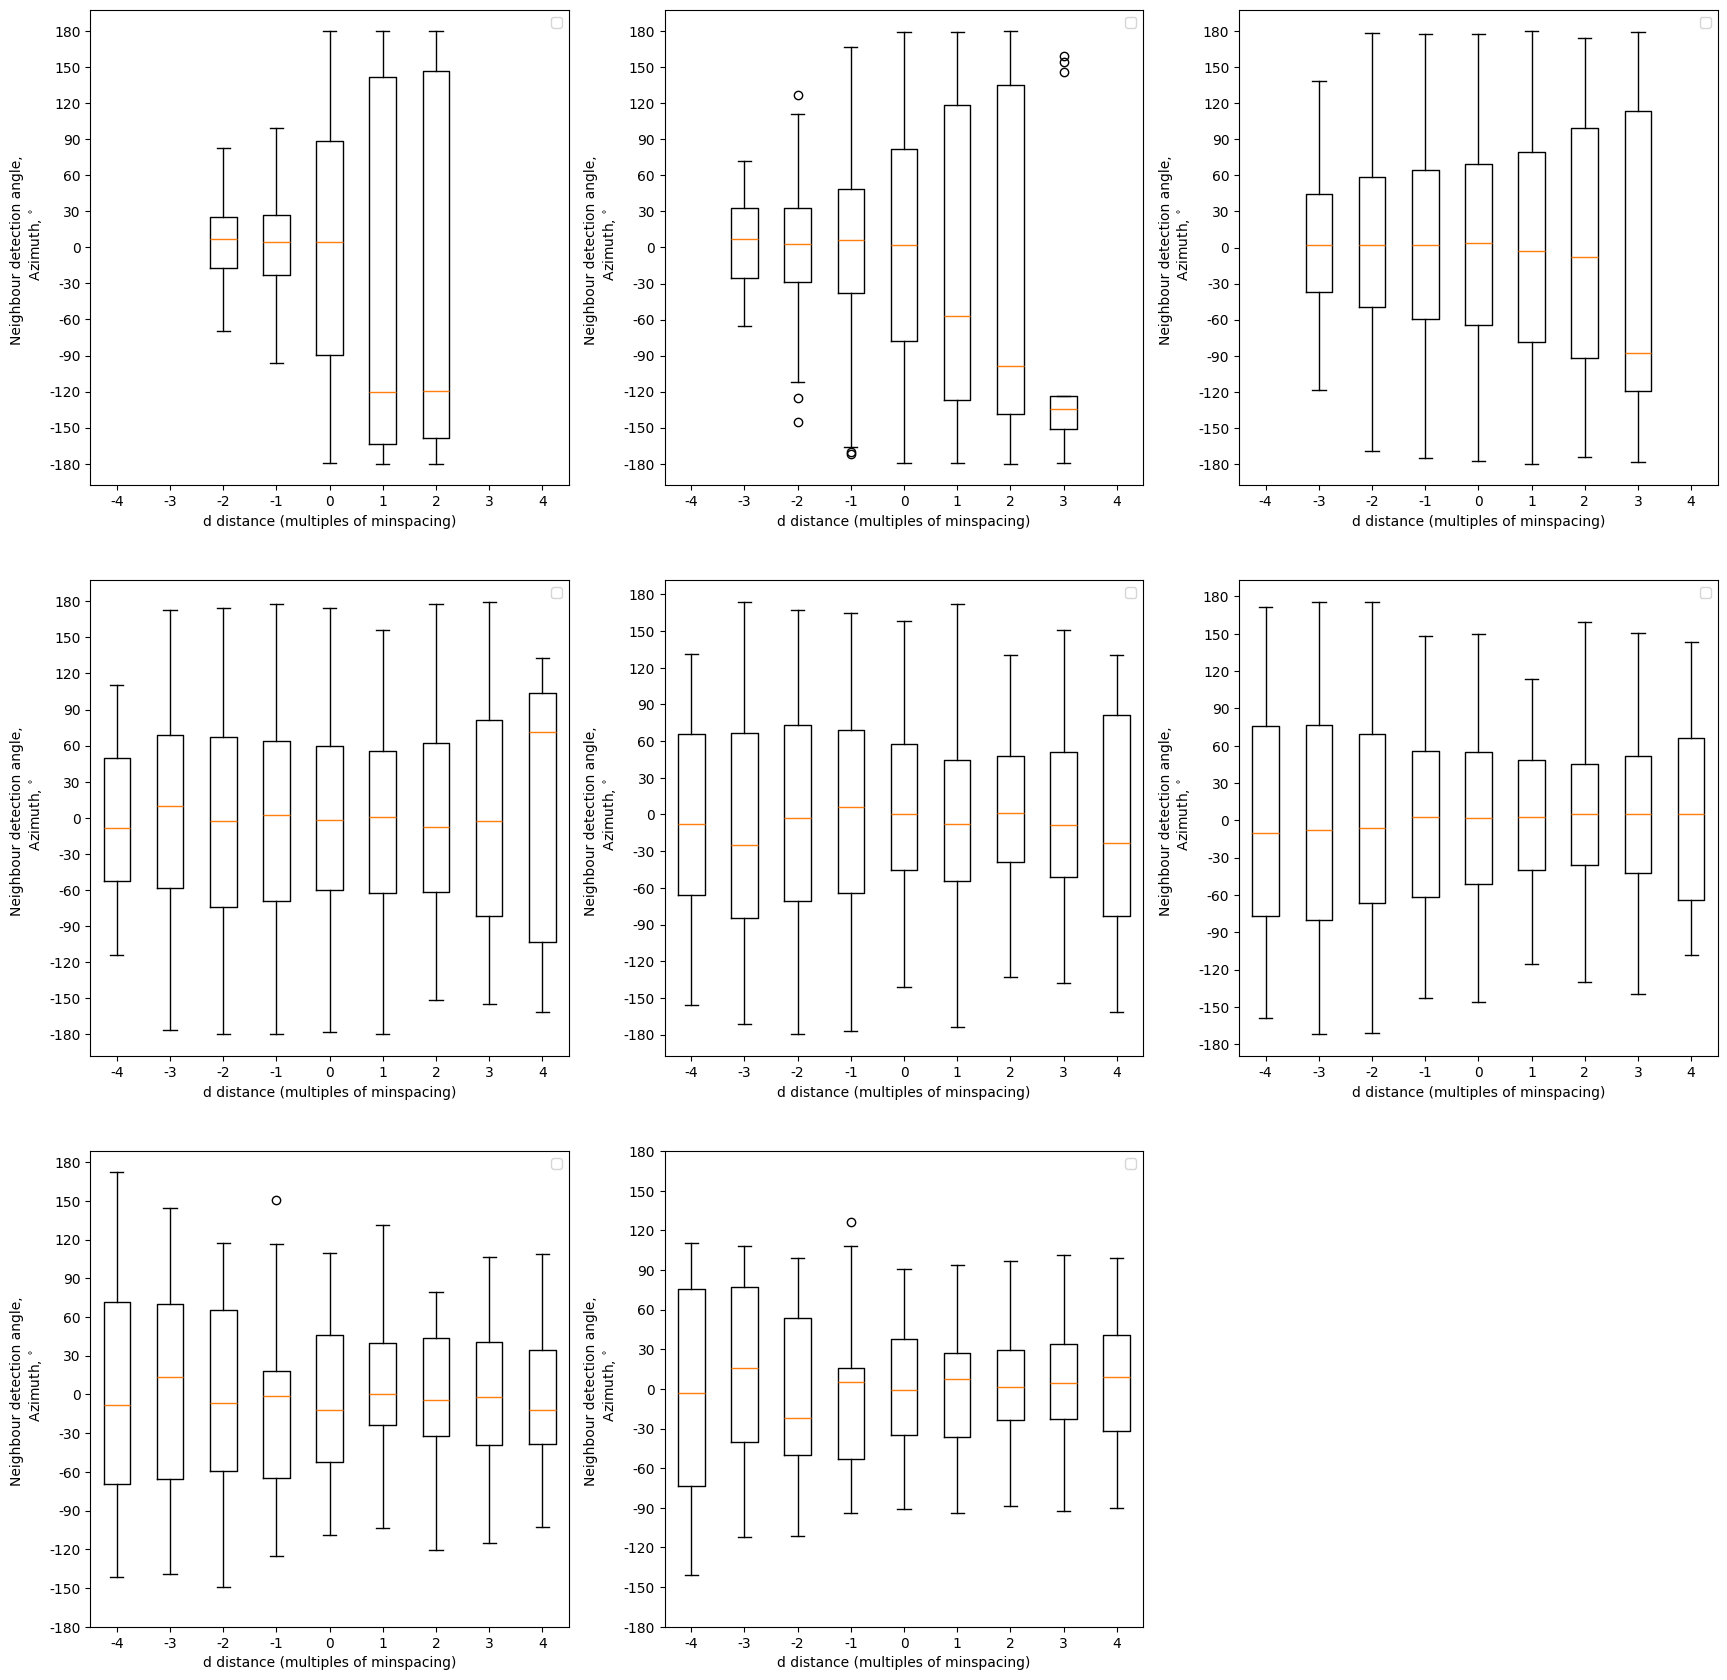

In [ ]:
i=0; 
d_distances_along_transect= np.arange(-4,5,1)
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize= (21,21))
group_sizes = [5, 10, 20, 30, 40, 50, 75, 100]
for group_size in group_sizes:
        array_storing_info_for_plot= []
        iterant_sign=-1
        x_ticks=[]
        for key in d_distances_along_transect:
                iterant_sign+=1
                nbrs_detected_data= store_probability_of_detection_n_neighbour[key]
                data_to_store= nbrs_detected_data['neighbours_azimuth'][group_sizes.index(group_size)]
                array_storing_info_for_plot.append(data_to_store)
                x_ticks.append(key)

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(array_storing_info_for_plot);

        plt.yticks(np.arange(-180,210,30), np.arange(-180,210,30), fontsize=10)
        plt.xticks(np.arange(1,len(x_ticks)+1), x_ticks, fontsize=10)

        plt.ylabel('Neighbour detection angle, \n  Azimuth, $^{\circ}$', fontsize=10)
        plt.xlabel('d distance (multiples of minspacing)', fontsize=10)
        plt.legend()
        print(key_for_dict)
        i+=1

In [ ]:
class No_situation_for_given_nd(Exception):
    """Still an exception raised when uncommon things happen"""
    def __init__(self, message, payload=None):
        self.message = message
        self.payload = payload # you could add more args
    def __str__(self):
        return str(self.message)

In [ ]:
try:
    raise No_situation_for_given_nd(f"Failure to generate scenario in which there exists no point that is {1} number of step(s) away from the centermost bat")
except No_situation_for_given_nd as error:
    print(str(error)) # Very bad mistake
print(omg)

Failure to generate scenario in which there exists no point that is 1 number of step(s) away from the centermost bat


NameError: name 'omg' is not defined

In [ ]:
raise No_situation_for_given_nd(f"Failure to generate scenario in which there exists no point that is {1} number of step(s) away from the centermost bat")
print("omg")

No_situation_for_given_nd: Failure to generate scenario in which there exists no point that is 1 number of step(s) away from the centermost bat